# Машинное обучение, ФКН ВШЭ

# Практическое задание 6. Бустинговое

## Общая информация

Дата выдачи: 08.12.2025

Мягкий дедлайн: 19.12.2025 23:59 MSK

Жёсткий дедлайн: 22.12.2025 23:59 MSK

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-06-Username.ipynb
* Модуль boosting.py

Username — ваша фамилия на латинице

## О задании

В этом задании вам предстоит вручную запрограммировать один из самых мощных алгоритмов машинного обучения — бустинг. Однако с большой силой приходит и большая ответственность, поэтому придется научиться им пользоваться

In [155]:
from warnings import filterwarnings

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set(style='darkgrid')
filterwarnings('ignore')

Мы будем работать с датасетом по предсказанию гендера. Никакие фичи мы придумывать не будем, но если вам интересно, в датасете имеется:

- region — регион, в котором проводили опрос
- age — возраст опрошенного
- year — год опроса
- race — этническая принадлежность
- sch — количество классов образования
- empstat — статус трудоустройства
- occ — код профессии
- ind — код индустрии, в которой человек работает
- annhrs — число часов работы в год
- hrwage — почасовая оплата
- icwage — суммарная оплата в год
- occupation — должность

Целевая метрика ROC-AUC, потому что мы непритязательны и это не фокус этой домашки



In [158]:
df = pd.read_parquet("boosting_dataset.pq")

X = df.drop("sex", axis=1)
y = df["sex"]

Пока что мы временно выкинем колонку с должностью, но мы к ней обязательно вернемся

Разделим на обучающую, валидационную и тестовую выборки (оставьте `random_state=1337` для воспроизводимости).

In [161]:
X_train, X_test, y_train, y_test = train_test_split(
    X.drop("occupation", axis=1).values, y.values, test_size=0.2, random_state=1337
)
X_test, X_valid, y_test, y_valid = train_test_split(
    X_test, y_test, test_size=0.5, random_state=1337
)

X_train.shape, X_valid.shape, X_test.shape

((8000, 11), (1000, 11), (1000, 11))

---

## Задание 1. Базовый градиентный бустинг (4 балла)

Первая часть посвящена реализации собственного градиентного бустинга. Обращаем внимание, что пользоваться готовыми реализациями <font color='lightcoral'>**нельзя**</font>, если специально не оговорено. На все <font color='#b962c4'>**вопросы**</font> должен быть <font color='#b962c4'>**ответ**</font>. В заданиях, где нужно делать параметры, часто есть референсы из других библиотек. На случай, если объяснение из ноутбука непонятно, советуем обратиться к соответствующей документации и пощупать, как это делается там

Вам нужно дописать код в файлике `boosting.py`. Для вас уже подготовлен шаблон класса `Boosting`, вы можете менять его по своему усмотрению.

### Инструкции для функций:

#### `__init__`

Существующие параметры:
- `base_model_class` — класс базовой модели нашего бустинга
- `base_model_params` — словарь с гиперпараметрами для базовой модели
- `n_estimators` — какое количество базовых моделей нужно обучить
- `learning_rate` — темп обучения, должен быть из полуинтервала $(0, 1]$
- `random_state`— в роли рандом стейта
- `verbose` — для тех, кому не нравится загадочность, можно включить и увидеть, сколько еще ждать конца обучения

#### `fit`

В `fit` приходит выборка, на которой мы обучаем новые базовые модели

1. Сначала нам нужно сделать какую-то нулевую модель, сделать предсказания (в шаблоне это нулевая модель, соответственно предсказания это просто `np.zeros`).
2. После этого нужно обучить `n_estimators` базовых моделей (как и на что обучаются базовые модели смотрите в лекциях и семинарах).
3. После каждой обученной базовой модели мы должны обновить текущие предсказания, посчитать ошибку на выборке (используем `loss_fn` для этого) и найти новую оптимальную гамму

#### `partial_fit`

В `partial_fit` передаются данные `X: np.ndarray, y: np.ndarray` для одного шага бустинга: обучаем следующую базовую модель на антиградиенте и обновляем ансамбль.

#### `predict_proba`

В `predict_proba` приходит любая выборка, нужно предсказать вероятности для неё. Суммируем предсказания базовых моделей на этой выборке (не забываем про гаммы) и накидываем сигмоиду

In [164]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [166]:
%autoreload 2

from boosting import Boosting

### Проверка кода

In [169]:
boosting = Boosting(
    verbose=True,
    random_state=69, # не забывайте фиксировать, пожалуйста
)

boosting.fit(X_train, y_train)

assert len(boosting.models) == boosting.n_estimators
assert len(boosting.gammas) == boosting.n_estimators

assert boosting.predict_proba(X_test).shape == (X_test.shape[0], 2), "prediction shapes are incorrect"
assert np.array_equal(boosting.history["train_loss"], np.sort(boosting.history["train_loss"])[::-1]), "train loss is not decreasing"

assert boosting.predict_proba(X_test).shape == (X_test.shape[0], 2)

# здесь и далее работаем с метрикой ROC-AUC
print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(X_test, y_test):.4f}')

Train ROC-AUC 1.0000
Valid ROC-AUC 0.7245
Test ROC-AUC 0.7533


Хорошим знаком будет ROC-AUC в районе 0.7, в зависимости от сида. Дефолтные параметры специально такие, чтобы прогнать модель быстро, поэтому не отчаивайтесь

---

## Задание 2. Имплементация гиперпараметров (3.5 балла | 3 бонус)

Бустинг, как метод агрегации, предлагает несколько вариантов регуляризации.

В этом пункте мы будем делать кучу самых разных гиперпараметров, каждый из них прекрасен по-своему, но полноценно их эффект получится ощутить лишь на этапе их перебора (кроме, пожалуй, `rsm`), поэтому делать третью часть до второй не рекомендуется

<font color='lightcoral'>**Важно!**</font> После добавления каждого параметра проверьте, как это повлияет на качество. Специально крутить параметры не нужно, но важно увидеть, что перформанс модели изменился, в худшую или в лучшую сторону. Для этого какие-то параметры нужны, пусть и от балды, <font color='lightcoral'>**гарантии, что дефолтные параметры подойдут, нет**</font>. Лучше всего это видно по графикам обучения <font color='lightcoral'>**на трейне и валидации**</font>, рекомендуется смотреть именно на них

### 2.1. Борьба с переобучением (1 балл)

Как известно, бустинги бывают склонны к переобучению. Чтобы этого не допустить, можно контролировать процесс обучения и проверять критерий останова на валидации прямо во время обучения. Реализуйте такую процедуру, не забудьте, что всю предобработку, что вы будете в дальнейшем делать для трейна, нужно будет повторить на валидации

Добавьте в вашу модель:
- `early_stopping_rounds: int | None = 0` — число раундов для критерия останова. Если качество ухудшается на протяжении всех раундов подряд, останавливаем обучение
- `eval_metric: str | None = None` — метрика, на которую смотрим, чтобы остановить обучение, может быть ключом из `model.history`
- `plot_history(self, keys: str | Iterable[str])` — метод, который строит график изменения метрики по ключам из `model.history`

И конкретно в метод `model.fit`:
- `eval_set: Tuple[np.ndarray] | None = None` — валидационная выборка `X_valid: np.ndarray, y_valid: np.ndarray`, на которой будем проверять переобучение
- `use_best_model: bool = False` — использовать лучшую модель, или нет. Если да, то отрезаем гаммы и модели вплоть до той, на которой остановились, минус `early_stopping_rounds`, т.е самой лучшей, после которой качество только падает

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td colspan="3" align="center"><code>early_stopping_rounds</code>, <code>eval_set</code></td>
</tr>
</table>

</div>

Продемонстрируйте, что все работает

All basic assertions passed!
Train ROC-AUC 1.0000
Valid ROC-AUC 0.7224
Test ROC-AUC 0.7482


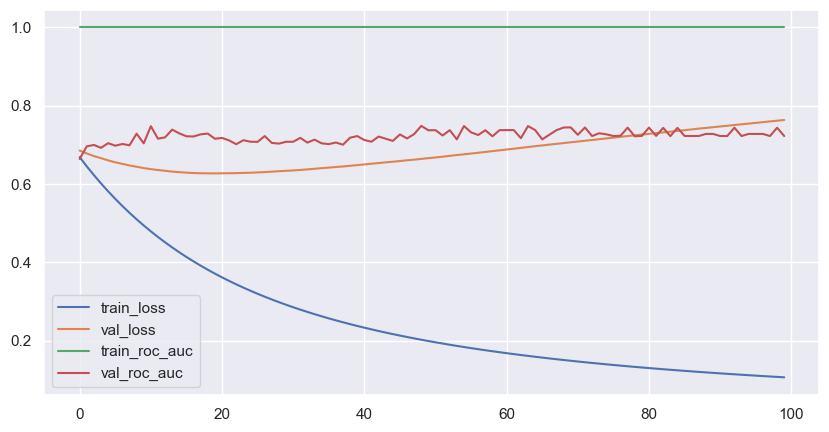


Testing Early Stopping
Stopped at iteration: 11
Final Valid ROC-AUC (Best Model): 0.7483


In [174]:
boosting = Boosting(
    n_estimators=100,
    learning_rate=0.1,
    early_stopping_rounds=None, # Для теста monotonic loss лучше пока выключить ES или поставить большим
    verbose=True,
    random_state=69 
)


boosting.fit(X_train, y_train, eval_set=(X_valid, y_valid))

assert len(boosting.models) == boosting.n_estimators
assert len(boosting.gammas) == boosting.n_estimators

assert boosting.predict_proba(X_test).shape == (X_test.shape[0], 2), "prediction shapes are incorrect"

train_losses = boosting.history["train_loss"]
assert np.all(np.diff(train_losses) <= 1e-9), "train loss is not decreasing monotonically"

print("All basic assertions passed!")


print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(X_test, y_test):.4f}')

boosting.plot_history(["train_loss", "val_loss", "train_roc_auc", "val_roc_auc"])

print("\nTesting Early Stopping")
boosting_es = Boosting(
    n_estimators=500, 
    learning_rate=0.1,
    early_stopping_rounds=10, 
    eval_metric='val_roc_auc', 
    random_state=69
)
boosting_es.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)

print(f"Stopped at iteration: {len(boosting_es.models)}")
print(f"Final Valid ROC-AUC (Best Model): {boosting_es.score(X_valid, y_valid):.4f}")

### Бонус. Бустинг линейных моделей (0.5 балла)

<font color='#b962c4'>**Вопрос:** что произойдет при ансамблировании линейных моделей? Имеет ли это смысл?</font>

<font color='#b962c4'>**Ответ:** При ансамблировании линейных моделей на выходе мы получим ту же линейную модель, грубо говоря, смысла в этом мало. Однако это может быть полезно в ситуациях отличных от рассматриваемых, например, для bag-of-words в текстах.</font>

Давайте убедимся. Обучите бустинг, где в качестве базовой модели будет линейная регрессия. Обязательно сохраните историю функции потерь и зафиксируйте время обучения. Можно взять уже готовый из <font color='#2f82d4'>**XGBoost**</font>, но будьте готовы разобраться с тем, как оттуда достать историю обучения

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>XGBClassifier(booster="gblinear")</code></td>
<td align="center">-</td>
<td align="center">-</td>
</tr>
</table>

</div>

XGBoost (gblinear) Training time: 0.0654 seconds
XGBoost Test ROC-AUC: 0.7385


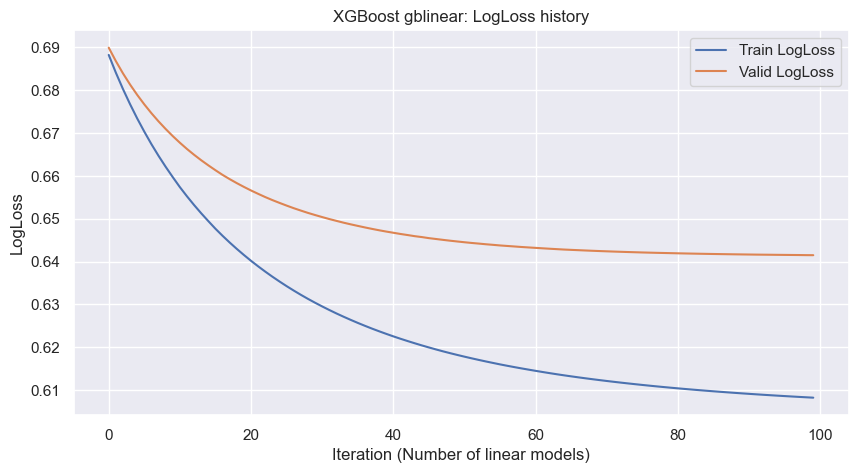

[0.6416309421887417,
 0.6416082437863515,
 0.6415902696984122,
 0.6415756484444064,
 0.6415570993337678,
 0.6415410890895072,
 0.6415250333273507,
 0.6415097286899109,
 0.6414864856833228,
 0.6414754253064093]

In [178]:
import time
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

y_train_mapped = np.where(y_train == -1, 0, y_train)
y_valid_mapped = np.where(y_valid == -1, 0, y_valid)
y_test_mapped = np.where(y_test == -1, 0, y_test)

xgb_linear = xgb.XGBClassifier(
    booster='gblinear',
    n_estimators=100,
    learning_rate=0.1,
    random_state=888,
    n_jobs=-1,
    eval_metric='logloss',
    objective='binary:logistic'
)

start_time = time.time()

xgb_linear.fit(
    X_train, y_train_mapped,
    eval_set=[(X_train, y_train_mapped), (X_valid, y_valid_mapped)],
    verbose=False
)

end_time = time.time()
xgb_training_time = end_time - start_time

# Сохраняем историю 
results = xgb_linear.evals_result()
xgb_train_loss = results['validation_0']['logloss']
xgb_valid_loss = results['validation_1']['logloss']

print(f"XGBoost (gblinear) Training time: {xgb_training_time:.4f} seconds")
print(f"XGBoost Test ROC-AUC: {roc_auc_score(y_test_mapped, xgb_linear.predict_proba(X_test)[:, 1]):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(xgb_train_loss, label='Train LogLoss')
plt.plot(xgb_valid_loss, label='Valid LogLoss')
plt.title('XGBoost gblinear: LogLoss history')
plt.xlabel('Iteration (Number of linear models)')
plt.ylabel('LogLoss')
plt.legend()
plt.grid(True)
plt.show()

xgb_valid_loss[-10:]

Теперь возьмите `sklearn.linear_model.SGDClassifier` и обучите на тех же данных. Не забудьте понять, как вытащить оттуда историю функции потерь

In [181]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss

n_epochs = 100
sgd_model = SGDClassifier(
    loss='log_loss', 
    penalty='l2', 
    alpha=0.88, 
    learning_rate='optimal', 
    random_state=888, 
    n_jobs=-1
)

sgd_train_loss = []
sgd_valid_loss = []
classes = np.unique(y_train_mapped) 


start_time = time.time()

for epoch in range(n_epochs):
    sgd_model.partial_fit(X_train, y_train_mapped, classes=classes)
    
    y_train_pred_prob = sgd_model.predict_proba(X_train)
    y_valid_pred_prob = sgd_model.predict_proba(X_valid)
    
    sgd_train_loss.append(log_loss(y_train_mapped, y_train_pred_prob))
    sgd_valid_loss.append(log_loss(y_valid_mapped, y_valid_pred_prob))

end_time = time.time()
sgd_training_time = end_time - start_time

print(f"SGDClassifier Training time: {sgd_training_time:.4f} seconds")
print(f"SGD Test ROC-AUC: {roc_auc_score(y_test_mapped, sgd_model.predict_proba(X_test)[:, 1]):.4f}")

SGDClassifier Training time: 0.7389 seconds
SGD Test ROC-AUC: 0.7103


Покажите на одном графике изменение функции потерь для бустинга и SGD классификатора. Сравните следующие детали у бустинга и линейной модели:

- время обучения
- сходимость (как быстро, как стабильно и прочее)
- графики функции потерь на трейне и на валидации

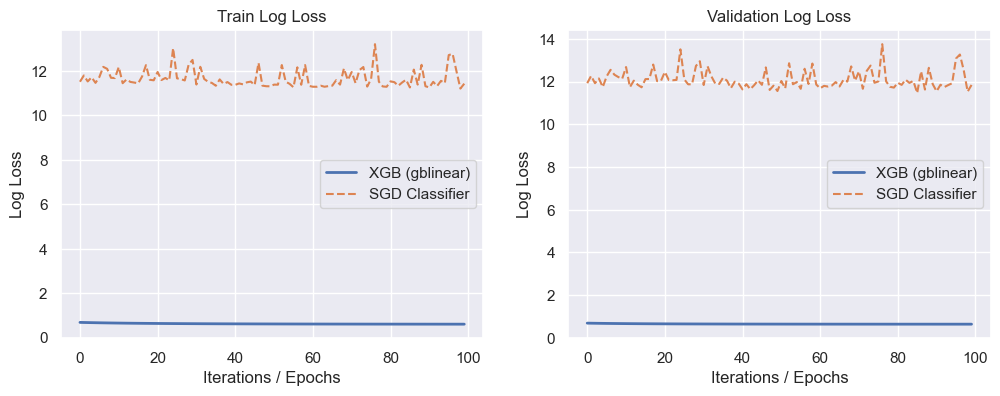

Время обучения XGBoost (gblinear): 0.06540 сек
Время обучения SGDClassifier:      0.73888 сек
1. Время: SGDClassifier обычно работает дольше в данном сетапе из-за ручного подсчета лосса
   в питоновском цикле (predict_proba на каждой итерации тяжелый).
   В чистом виде без логов SGD обычно быстрее или сопоставим.
2. Сходимость: XGBoost (gblinear) использует координатный спуск или L-BFGS (зависит от настроек),
   поэтому его график более гладкий и монотонный. SGD — стохастический градиентный спуск,
   поэтому кривая может 'шуметь' и сходиться медленнее или скачками.


In [184]:
plt.figure(figsize=(12, 4))

# для трейна
plt.subplot(1, 2, 1)
plt.plot(xgb_train_loss, label='XGB (gblinear)', linewidth=2)
plt.plot(sgd_train_loss, label='SGD Classifier', linestyle='--')
plt.title('Train Log Loss')
plt.xlabel('Iterations / Epochs')
plt.ylabel('Log Loss')
plt.legend()

# для валидации
plt.subplot(1, 2, 2)
plt.plot(xgb_valid_loss, label='XGB (gblinear)', linewidth=2)
plt.plot(sgd_valid_loss, label='SGD Classifier', linestyle='--')
plt.title('Validation Log Loss')
plt.xlabel('Iterations / Epochs')
plt.ylabel('Log Loss')
plt.legend()

plt.show()

print(f"Время обучения XGBoost (gblinear): {xgb_training_time:.5f} сек")
print(f"Время обучения SGDClassifier:      {sgd_training_time:.5f} сек")
print("1. Время: SGDClassifier обычно работает дольше в данном сетапе из-за ручного подсчета лосса")
print("   в питоновском цикле (predict_proba на каждой итерации тяжелый).")
print("   В чистом виде без логов SGD обычно быстрее или сопоставим.")
print("2. Сходимость: XGBoost (gblinear) использует координатный спуск или L-BFGS (зависит от настроек),")
print("   поэтому его график более гладкий и монотонный. SGD — стохастический градиентный спуск,")
print("   поэтому кривая может 'шуметь' и сходиться медленнее или скачками.")

<font color='#b962c4'>**Вопрос:** Какой вывод вы можете сделать?</font>

<font color='#b962c4'>**Ответ:** ...</font>

### 2.2. Категории 2.0 (0.75 балла)

Пока что для простоты картины мы игнорировали категориальные признаки. <font color='#c4bf0a'>CatBoost</font> в частности предлагает один из самых эффективных и быстрых вариантов кодировки категорий, который мы попробуем повторить

> Основная идея в том, что важны не сами категории, а значения целевой переменной, которые имеют объекты этой категории. Каждый категориальный признак мы заменим средним значением целевой переменной по всем объектам этой же категории:

$$
g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1]}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)]}
$$


Добавьте в модель вот это:
- `cat_features: Iterable | None` — категориальные признаки для кодирования
- `_cat_fit(self, X: np.array, y: np.ndarray)` — внутренний метод для построения счетчиков
- `_cat_transform(self, X: np.ndarray)` — внутренний метод для применения счетчиков

Либо сделайте энкодер отдельным классом с аналогичными методами `fit` и `transform`, это даже лучше. Его нужно прогнать всего раз для каждой из выборок

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center">-</td>
<td align="center">-</td>
<td align="center"><code>cat_features</code></td>
</tr>
</table>

</div>

Закодируйте переменные, которые вы хотите считать категориальными, с помощью счётчиков (готовые реализации брать нельзя) и покажите эффект. Помните, что все должно быть векторизовано и красиво

In [188]:
# вернем occupation туда, где ему самое место, но это не единственная кат фича!

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, random_state=1337
)
X_test, X_valid, y_test, y_valid = train_test_split(
    X_test, y_test, test_size=0.5, random_state=1337
)

X_train.shape, X_valid.shape, X_test.shape

((8000, 12), (1000, 12), (1000, 12))

In [190]:
from sklearn.base import BaseEstimator, TransformerMixin

class TargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cat_features: list[int], alpha: float = 10.0):
        self.cat_features = cat_features
        self.alpha = alpha
        self.mappings = {}
        self.global_mean = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        df = pd.DataFrame(X)
        self.global_mean = np.mean(y)

        for col_idx in self.cat_features:
            stats = pd.DataFrame({'y': y, 'group': df[col_idx]}).groupby('group')['y'].agg(['sum', 'count'])
            
            # Сглаженное среднее
            smoothed_mean = (stats['sum'] + self.alpha * self.global_mean) / (stats['count'] + self.alpha)
            
            self.mappings[col_idx] = smoothed_mean.to_dict()
            
        return self

    def transform(self, X: np.ndarray):
        X_transformed = X.copy()
        df = pd.DataFrame(X_transformed)

        for col_idx in self.cat_features:
            if col_idx in self.mappings:
                mapped_col = df[col_idx].map(self.mappings[col_idx]).fillna(self.global_mean)
                X_transformed[:, col_idx] = mapped_col.values
        
        return X_transformed.astype(float)

In [233]:
cat_cols_indices = [0, 3, 5, 6, 7, 11]

y_train_bin = np.where(y_train == -1, 0, y_train)
y_valid_bin = np.where(y_valid == -1, 0, y_valid)
y_test_bin = np.where(y_test == -1, 0, y_test)

encoder = TargetEncoder(cat_features=cat_cols_indices, alpha=10.0)

encoder.fit(X_train, y_train_bin)

X_train_enc = encoder.transform(X_train)
X_valid_enc = encoder.transform(X_valid)
X_test_enc = encoder.transform(X_test)

print("Размерность:", X_train_enc.shape)
print("Пример закодированного столбца Occupation:")
print(X_train_enc[:5, 11]) 


model_enc = Boosting(
    base_model_params={'max_depth': 3, 'min_samples_leaf': 10}, 
    n_estimators=50,
    learning_rate=0.1,
    random_state=888, 
    early_stopping_rounds=10,
    eval_metric='val_roc_auc',
    verbose=True
)

print("\nОбучение бустинга на закодированных данных")
model_enc.fit(
    X_train_enc, y_train_bin, 
    eval_set=(X_valid_enc, y_valid_bin),
    use_best_model=True
)

score = model_enc.score(X_test_enc, y_test_bin) 
print(f"\n ROC-AUC on Test with TE: {score:.4f}")

Размерность: (8000, 12)
Пример закодированного столбца Occupation:
[0.45628302 0.58119898 0.49065957 0.79695533 0.79695533]

Обучение бустинга на закодированных данных

 ROC-AUC on Test with TE: 0.8387


### Бонус. Категории 3.0 (0.5 балла)

Увы, закодированные признаки сами по себе являются классификаторами и, обучаясь на них, мы допускаем утечку целевой переменной в признаки, но с этим можно жить, в частности это одна из главных фишек <font color='#c4bf0a'>CatBoost</font>, была. Почитайте [статью](https://arxiv.org/pdf/1706.09516), она интересная

Реализуйте подсчет счетчиков так, чтобы кодировка категории была только по объектам. расположенным выше в датасете (например, если у нас выборка отсортирована по времени)

Методы добавлять не нужно, разве что очень хочется, предполагается, что это дефолтное поведение бустинга, на самом деле, если не нужен `OneHotEncoder `

In [236]:
from typing import List, Optional

class OrderedTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cat_features: List[int], random_state: Optional[int] = None):
        self.cat_features = cat_features
        self.random_state = random_state
        self.mappings = {} 
        self.global_mean = 0.0

    def fit(self, X: np.ndarray, y: np.ndarray):
        df = pd.DataFrame(X)
        self.global_mean = np.mean(y)
        
        for col_idx in self.cat_features:
            stats = pd.DataFrame({'y': y, 'group': df[col_idx]}).groupby('group')['y'].mean()
            self.mappings[col_idx] = stats.to_dict()
        
        return self

    def transform(self, X: np.ndarray, y: Optional[np.ndarray] = None, is_train: bool = False):
        X_transformed = X.copy()
        n_samples = X.shape[0]

        if is_train and y is not None:
            rng = np.random.default_rng(self.random_state)
            shuffled_indices = rng.permutation(n_samples)
            inverse_indices = np.argsort(shuffled_indices)

            y_shuffled = y[shuffled_indices]

            for col_idx in self.cat_features:
                col_vals = X[:, col_idx][shuffled_indices]

                temp_df = pd.DataFrame({'feature': col_vals, 'target': y_shuffled})

                grouped = temp_df.groupby('feature')['target']

                cumsum = grouped.cumsum().shift(1).fillna(0).values
                cumcount = grouped.cumcount().values

                encoded_values = np.full(n_samples, self.global_mean)
                mask = cumcount > 0
                encoded_values[mask] = cumsum[mask] / cumcount[mask]

                X_transformed[:, col_idx] = encoded_values[inverse_indices]

        else:
            for col_idx in self.cat_features:
                col_vals = X_transformed[:, col_idx]
                mapping = self.mappings.get(col_idx, {})
                mapped_col = pd.Series(col_vals).map(mapping).fillna(self.global_mean).values
                X_transformed[:, col_idx] = mapped_col

        return X_transformed.astype(float)

In [246]:
cat_cols_indices = [0, 3, 5, 6, 7, 11]

y_train_bin = np.where(y_train == -1, 0, y_train)
y_valid_bin = np.where(y_valid == -1, 0, y_valid)
y_test_bin = np.where(y_test == -1, 0, y_test)

encoder = OrderedTargetEncoder(cat_features=cat_cols_indices, random_state=888,)

encoder.fit(X_train, y_train_bin)

X_train_enc = encoder.transform(X_train, y=y_train_bin, is_train=True)
X_valid_enc = encoder.transform(X_valid)
X_test_enc = encoder.transform(X_test)

print("Размерность:", X_train_enc.shape)
print("Пример закодированного столбца:")
print(X_train_enc[:5, 11]) 


model_enc = Boosting(
    base_model_params={'max_depth': 3, 'min_samples_leaf': 10},
    n_estimators=500,
    learning_rate=0.88, 
    early_stopping_rounds=10,
    eval_metric='val_roc_auc',
    verbose=True
)

print("\nОбучение бустинга на закодированных данных")
model_enc.fit(
    X_train_enc, y_train_bin, 
    eval_set=(X_valid_enc, y_valid_bin),
    use_best_model=True
)


score = model_enc.score(X_test_enc, y_test_bin) 
print(f"\nROC-AUC on Test with TE: {score:.4f}")

Размерность: (8000, 12)
Пример закодированного столбца:
[0.0754717  0.13157895 0.56900726 0.79755435 0.27667269]

Обучение бустинга на закодированных данных
Stop at 40. Best: 31

ROC-AUC on Test with TE: 0.7270


### 2.3. Бутстрап (0.75 балла)
Как известно, при обучении базовых алгоритмов в беггинге, используется бутстрапированная выборка. Звучит хайпово, почему бы не попробовать сделать то же самое в бустинге?

> Идея, которая за этим стоит проста - бустинги переобучаются, как черти. Бутстрап же может сделать процесс куда более робастным и быть одним из способов регуляризации, а заодно уменьшить время обучения, в случае бутстрапа Бернулли

Вам нужно реализовать параметры:
- `subsample: float = 1.0` — доля объектов, на которой будет обучаться базовая модель (какую часть составляет бутстрапная выборка от исходной обучающей). Соответствует бутстрапу типа `Bernoulli`. Каждый объект либо входит в подвыборку, либо нет
- `bagging_temperature: float = 1.0` — температура для генерации весов. Соответствует бутстрапу типа `Bayesian`. Каждому объекту присваивается вес $w$, который получается из температуры $t$, после чего объект, в количестве $w$, попадает в выборку. \
$w = (-\log(X))^t$, где $X \sim {U[0, 1]}$ \
Таким образом можно сделать симуляцию повторений, обобщив на непрерывный случай. Обычный бутстрап не умеет сэмплировать дробное число объектов, но можно сделать примерно то же самое, если размножить объект $w$ раз, либо присвоить вес. Подумайте, как это корректно реализовать в бустинге
- `bootstrap_type: str | None = 'Bernoulli'` — тип бутстрапа

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>subsample</code>, -</td>
<td align="center"><code>subsample</code>, <code>bagging</code></td>
<td align="center"><code>subsample</code>, <code>bootstrap_type</code></td>
</tr>
</table>

</div>

<font color='#b962c4'>**Вопрос:** как бутстрап может помочь в обучении с точки зрения смещения, разброса и вообще?</font>

<font color='#b962c4'>**Ответ:** азброс (Variance): Бутстрап (сэмплирование объектов) и RSM (сэмплирование признаков) — это мощные методы уменьшения разброса. Поскольку каждое дерево теперь видит только часть данных или признаков, они меньше "подстраиваются" под шум в обучающей выборке. Это делает ансамбль более робастным (устойчивым).

Смещение (Bias): Использование подмножеств данных немного увеличивает смещение каждого отдельного дерева (так как у него меньше информации для обучения). Однако в бустинге это компенсируется большим количеством итераций, а итоговая модель обобщает лучше.

Декорреляция: RSM особенно полезен тем, что декоррелирует деревья. Если в данных есть один супер-сильный признак, без RSM он будет в корне каждого дерева. RSM заставляет модель искать другие зависимости, что делает ансамбль разнообразнее. </font>

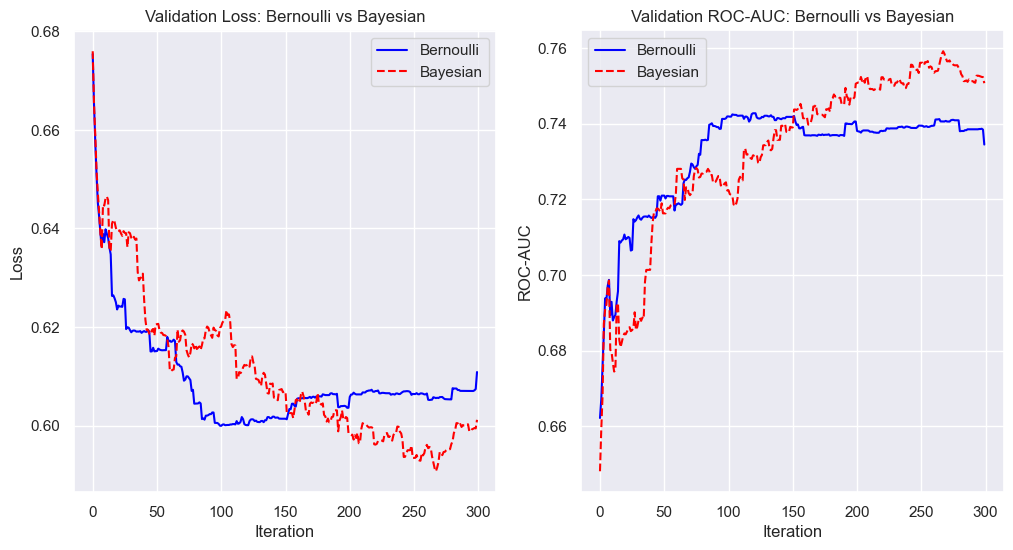

Test ROC-AUC (Bernoulli): 0.7359
Test ROC-AUC (Bayesian): 0.7460


In [261]:
N_ESTIMATORS = 300
RANDOM_SEED = 888
LR = 0.88

model_bernoulli = Boosting(
    n_estimators=N_ESTIMATORS, 
    learning_rate=LR, 
    bootstrap_type='Bernoulli',
    subsample=1.0,                
    base_model_params={'max_depth': 3, 'min_samples_leaf': 10},
    random_state=RANDOM_SEED,
    verbose=False
)

model_bayesian = Boosting(
    n_estimators=N_ESTIMATORS, 
    learning_rate=LR, 
    bootstrap_type='Bayesian',
    bagging_temperature=1.0,     
    base_model_params={'max_depth': 3, 'min_samples_leaf': 10},
    random_state=RANDOM_SEED,
    verbose=False
)

model_bernoulli.fit(X_train_enc, y_train_bin, eval_set=(X_valid_enc, y_valid_bin))

model_bayesian.fit(X_train_enc, y_train_bin, eval_set=(X_valid_enc, y_valid_bin))

plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
plt.plot(model_bernoulli.history['val_loss'], label='Bernoulli', color='blue')
plt.plot(model_bayesian.history['val_loss'], label='Bayesian', color='red', linestyle='--')
plt.title('Validation Loss: Bernoulli vs Bayesian')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(model_bernoulli.history['val_roc_auc'], label='Bernoulli', color='blue')
plt.plot(model_bayesian.history['val_roc_auc'], label='Bayesian', color='red', linestyle='--')
plt.title('Validation ROC-AUC: Bernoulli vs Bayesian')
plt.xlabel('Iteration')
plt.ylabel('ROC-AUC')
plt.legend()
plt.grid(True)

plt.show()

score_bern = model_bernoulli.score(X_test_enc, y_test_bin)
score_bayesian = model_bayesian.score(X_test_enc, y_test_bin)

print(f"Test ROC-AUC (Bernoulli): {score_bern:.4f}")
print(f"Test ROC-AUC (Bayesian): {score_bayesian:.4f}")

Помимо выбора случайных объектов, есть идея выбирать случайное подмножество признаков, заложенная в Random Forest. Мотивация это делать точно та же самая, что и в бутстрапировании, за это будет отвечать параметр `rsm`

В библиотеках это реализовано так:

<div align="center">

| <font color="#2f82d4">XGBoost</font> | <font color="#41a657">LightGBM</font> | <font color='#d1cd3b'>CatBoost</font> |
| :---: | :---: | :---: |
| `colsample_bytree`| `colsample_bytree`| `rsm`|

</div>

Нужно добавить параметр:
- `rsm: float = 1.0` — доля признаков, участвующих в обучении модели. Каждый признак либо входит, либо не входит в пул, на котором обучается базовый алгоритм, по аналогии с бутстрапом Бернулли

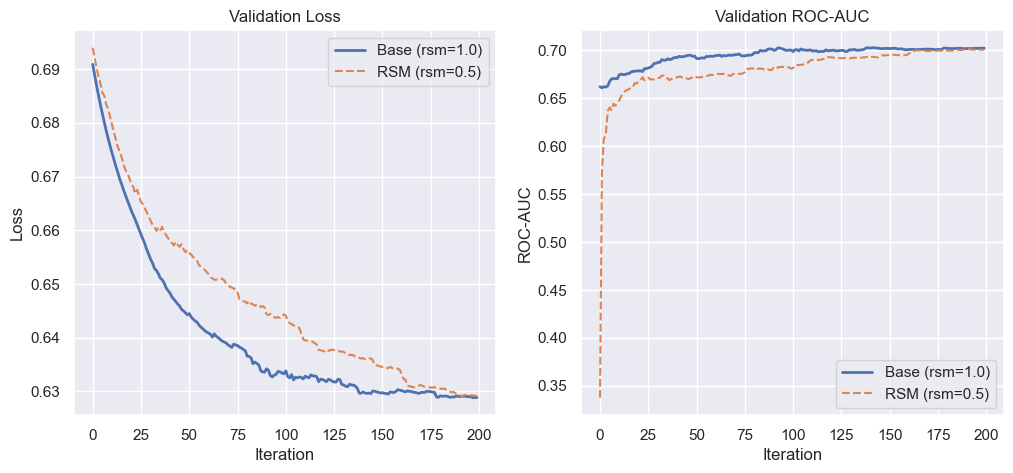


Результаты
Test ROC-AUC (Base, rsm=1.0): 0.7158
Test ROC-AUC (RSM, rsm=0.5): 0.7164


In [266]:
N_ESTIMATORS = 200

model_no_rsm = Boosting(
    n_estimators=N_ESTIMATORS, 
    learning_rate=0.1, 
    bootstrap_type='Bernoulli', 
    rsm=1.0,             
    base_model_params={'max_depth': 3, 'min_samples_leaf': 10},
    random_state=1337,
    verbose=False
)

model_rsm = Boosting(
    n_estimators=N_ESTIMATORS, 
    learning_rate=0.1, 
    bootstrap_type='Bernoulli',  
    rsm=0.5,              # 50% признаков
    base_model_params={'max_depth': 3, 'min_samples_leaf': 10},
    random_state=1337,
    verbose=False
)

model_no_rsm.fit(X_train_enc, y_train_bin, eval_set=(X_valid_enc, y_valid_bin))

model_rsm.fit(X_train_enc, y_train_bin, eval_set=(X_valid_enc, y_valid_bin))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model_no_rsm.history['val_loss'], label='Base (rsm=1.0)', linewidth=2)
plt.plot(model_rsm.history['val_loss'], label='RSM (rsm=0.5)', linestyle='--')
plt.title('Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(model_no_rsm.history['val_roc_auc'], label='Base (rsm=1.0)', linewidth=2)
plt.plot(model_rsm.history['val_roc_auc'], label='RSM (rsm=0.5)', linestyle='--')
plt.title('Validation ROC-AUC')
plt.xlabel('Iteration')
plt.ylabel('ROC-AUC')
plt.legend()

plt.show()

score_no_rsm = model_no_rsm.score(X_test_enc, y_test_bin)
score_rsm = model_rsm.score(X_test_enc, y_test_bin)

print("\nРезультаты")
print(f"Test ROC-AUC (Base, rsm=1.0): {score_no_rsm:.4f}")
print(f"Test ROC-AUC (RSM, rsm=0.5): {score_rsm:.4f}")

### Бонус. GOSS (0.5 балла)

Заметим, что во время обучения не все объекты одинаково важны. Один из вариантов это исправить — ввести какие-то веса на объекты, однако можно пойти чуть хитрее. В <font color='#53c96c'>**LightGBM**</font> придумали подход [Gradient-based One-side Sampling](https://www.microsoft.com/en-us/research/wp-content/uploads/2017/11/lightgbm.pdf)

> Давайте оценивать важность объектов в отдельный момент обучения нового дерева. Будем считать, какой антиградиент привносит каждый объект. Далее разобьем градиенты на 2 группы. Объекты с большими (по модулю) градиентами берутся все, с маленькими — только часть, по аналогии с бутстрапом. И не забываем домножить на фактор, чтобы учесть выкинутые объекты. Подробнее в статье

Параметры, которые нужно сделать:

- `goss: bool = False` — GOSS бустинг или нет
- `goss_k: float = 0.2` — доля объектов, градиенты которых будем считать большими. Все остальное — маленькими
- `subsample: float = 0.3` — параметры сэмплинга Бернулли для маленьких градиентов из пункта 2.3

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center">-</td>
<td align="center"><code>bagging='goss'</code></td>
<td align="center"><code>bootstrap_type='MVS'</code></td>
</tr>
</table>

</div>

Сделайте и посмотрите

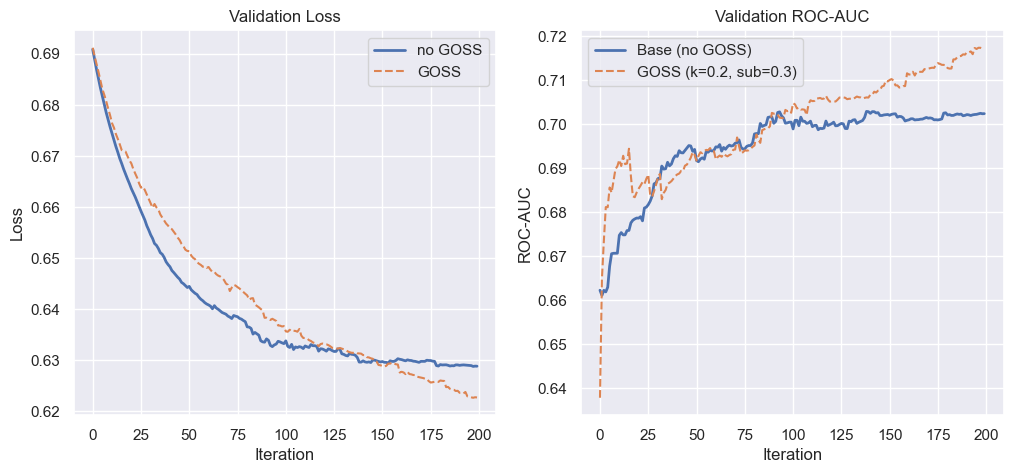


Результаты
Test ROC-AUC (no GOSS): 0.7158
Test ROC-AUC (GOSS): 0.7312


In [269]:
N_ESTIMATORS = 200

model_base = Boosting(
    n_estimators=N_ESTIMATORS, 
    learning_rate=0.1, 
    bootstrap_type=None,
    rsm=1.0,
    goss=False,
    base_model_params={'max_depth': 3, 'min_samples_leaf': 10},
    random_state=888,
    verbose=False
)


model_goss = Boosting(
    n_estimators=N_ESTIMATORS, 
    learning_rate=0.1, 
    bootstrap_type=None, 
    rsm=1.0,
    goss=True,
    goss_k=0.2, 
    subsample=0.3, 
    base_model_params={'max_depth': 3, 'min_samples_leaf': 10},
    random_state=888,
    verbose=False
)


model_base.fit(X_train_enc, y_train_bin, eval_set=(X_valid_enc, y_valid_bin))

model_goss.fit(X_train_enc, y_train_bin, eval_set=(X_valid_enc, y_valid_bin))


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model_base.history['val_loss'], label='no GOSS', linewidth=2)
plt.plot(model_goss.history['val_loss'], label='GOSS', linestyle='--')
plt.title('Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(model_base.history['val_roc_auc'], label='Base (no GOSS)', linewidth=2)
plt.plot(model_goss.history['val_roc_auc'], label='GOSS (k=0.2, sub=0.3)', linestyle='--')
plt.title('Validation ROC-AUC')
plt.xlabel('Iteration')
plt.ylabel('ROC-AUC')
plt.legend()

plt.show()

score_base = model_base.score(X_test_enc, y_test_bin)
score_goss = model_goss.score(X_test_enc, y_test_bin)

print("\nРезультаты")
print(f"Test ROC-AUC (no GOSS): {score_base:.4f}")
print(f"Test ROC-AUC (GOSS): {score_goss:.4f}")

### 2.4. Бинаризация (0.5 балла)

Вместо того, чтобы выкидывать признаки, можно попробовать проредить их множество значений, применив бинаризацию. В идеале это стоит делать с датасетом до обучения модели, но не обязательно, можно, например, на этапе `fit`, а в `partial_fit` приходит уже квантизованный датасет.

> Зачем это? Да все очень просто! Квантизованные данные весят гораздо меньше, значений в них куда как меньше, а значит, наше обучение пойдет гораздо быстрее, к тому же все снова станет устойчивее. Беда лишь в новых данных, которые могут оказаться вне бина, но великие силы избавили нас от этих проблем в нашем датасете. Фактически мотивация вновь та же, что у бутстрапа

Нужно добавить параметры:
- `quantization_type: str | None = None` — тип квантизации, если она есть
- `nbins: int = 255` — число бинов для квантизации. Игнорируем, если тип квантизации не указан

Либо сделать квантизатор отдельным классом, где в `fit` запоминаются пороги, а в `transform` преобразуются фичи

Рассмотрим варианта `quantization_type`:

- `'uniform'` — значения признака $[\min f_i, \max f_i]$ отображаются в `nbins` отрезков одинаковой длины, которые полностью покрывают интервал
- `'quantile'` — тот же самый отрезок сортируется и бьется на `nbins` квантилей от 0 до 1

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>tree_method</code></td>
<td align="center"><code>max_bin</code></td>
<td align="center"><code>quantize(...)</code></td>
</tr>
</table>

</div>

Разницу между ними вы можете увидеть на картинке, где квантизуется гауссиана

<img src="https://i.postimg.cc/gJ2SJgpN/image-2025-11-29-201502496.png">

Реализуйте их, примените их к числовым признакам, и покажите, что все работает четко

In [279]:
from typing import Literal

class FeatureQuantizer(BaseEstimator, TransformerMixin):
    def __init__(self, 
                 quantization_type: Literal['uniform', 'quantile'] | None = None, 
                 nbins: int = 255):
  
        self.quantization_type = quantization_type
        self.nbins = nbins
        self.bins_ = {}  
        self.numerical_features_indices = [] 

    def fit(self, X: np.ndarray, numerical_features_indices: list[int]):
        if self.quantization_type is None:
            return self
            
        self.numerical_features_indices = numerical_features_indices
        n_samples, n_features = X.shape

        for col_idx in self.numerical_features_indices:
            feature_data = X[:, col_idx].astype(float)
            
            feature_data = feature_data[~np.isnan(feature_data)]
            
            if len(feature_data) == 0:
                self.bins_[col_idx] = np.array([])
                continue
            
            if self.quantization_type == 'uniform':
                min_val = np.min(feature_data)
                max_val = np.max(feature_data)
                
                bins_edges = np.linspace(min_val, max_val, self.nbins + 1)[1:-1] 
                
                self.bins_[col_idx] = np.unique(bins_edges)

            elif self.quantization_type == 'quantile':
                quantiles = np.linspace(0, 1, self.nbins + 1)[1:-1] 
                
                bins_edges = np.quantile(feature_data, quantiles)
                
                self.bins_[col_idx] = np.unique(bins_edges)
            
            
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        if self.quantization_type is None:
            return X 
        
        X_quantized = X.copy()
        
        for col_idx in self.numerical_features_indices:
            if col_idx in self.bins_:
                bins_edges = self.bins_[col_idx]
                feature_data = X[:, col_idx].astype(float)

                quantized_col = np.digitize(feature_data, bins_edges, right=True)
                
                X_quantized[:, col_idx] = quantized_col.astype(int)

        return X_quantized.astype(float) 


Квантизация 'quantile' (nbins=10)
Исходное число уникальных значений в X_train[:, 1]: 40
Квантованное число уникальных значений: 10
Пример квантованных значений: [2 3 7 6 7 0 8 0 4 9]

Квантизация 'uniform' (nbins=10)
Исходное число уникальных значений в X_train[:, 1]: 40
Квантованное число уникальных значений: 10
Пример квантованных значений: [2 2 6 5 6 0 7 0 3 9]


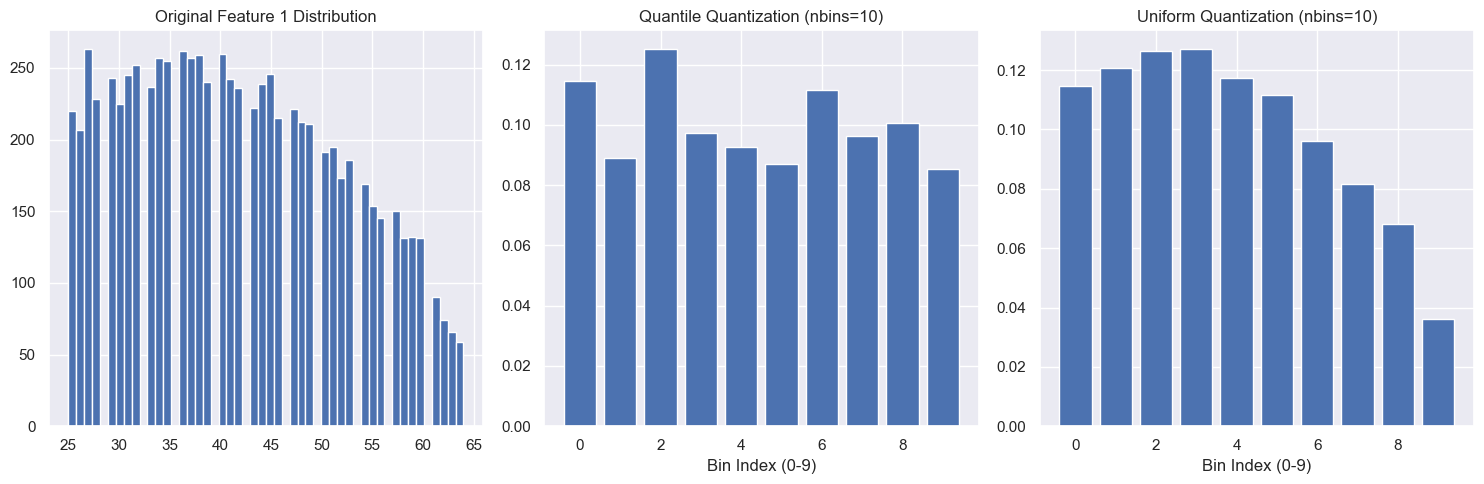

In [285]:
numerical_indices = [idx for idx in range(X_train.shape[1]) if idx not in cat_cols_indices]

quantizer_q = FeatureQuantizer(quantization_type='quantile', nbins=10) 

quantizer_q.fit(X_train, numerical_features_indices=numerical_indices)

X_train_quant_q = quantizer_q.transform(X_train_enc)
X_valid_quant_q = quantizer_q.transform(X_valid_enc)
X_test_quant_q = quantizer_q.transform(X_test_enc)

print("\nКвантизация 'quantile' (nbins=10)")
print(f"Исходное число уникальных значений в X_train[:, {numerical_indices[0]}]: {len(np.unique(X_train_enc[:, numerical_indices[0]])):}")
print(f"Квантованное число уникальных значений: {len(np.unique(X_train_quant_q[:, numerical_indices[0]]))}")
print(f"Пример квантованных значений: {X_train_quant_q[:10, numerical_indices[0]].astype(int)}")



quantizer_u = FeatureQuantizer(quantization_type='uniform', nbins=10)

quantizer_u.fit(X_train, numerical_features_indices=numerical_indices)

X_train_quant_u = quantizer_u.transform(X_train_enc)
X_valid_quant_u = quantizer_u.transform(X_valid_enc)
X_test_quant_u = quantizer_u.transform(X_test_enc)

print("\nКвантизация 'uniform' (nbins=10)")
print(f"Исходное число уникальных значений в X_train[:, {numerical_indices[0]}]: {len(np.unique(X_train_enc[:, numerical_indices[0]])):}")
print(f"Квантованное число уникальных значений: {len(np.unique(X_train_quant_u[:, numerical_indices[0]]))}")
print(f"Пример квантованных значений: {X_train_quant_u[:10, numerical_indices[0]].astype(int)}")


feature_to_plot = X_train[:, numerical_indices[0]]
feature_quant_q = X_train_quant_q[:, numerical_indices[0]]
feature_quant_u = X_train_quant_u[:, numerical_indices[0]]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(feature_to_plot, bins=50)
plt.title(f'Original Feature {numerical_indices[0]} Distribution')


plt.subplot(1, 3, 2)
plt.hist(feature_quant_q, bins=np.arange(11)-0.5, rwidth=0.8, density=True) 
plt.title('Quantile Quantization (nbins=10)')
plt.xlabel('Bin Index (0-9)')

plt.subplot(1, 3, 3)
plt.hist(feature_quant_u, bins=np.arange(11)-0.5, rwidth=0.8, density=True)
plt.title('Uniform Quantization (nbins=10)')
plt.xlabel('Bin Index (0-9)')

plt.tight_layout()
plt.show()

<font color='#b962c4'>**Вопрос**: как квантизация поможет в обработке выбросов и нанов?</font>

<font color='#b962c4'>**Ответ**: Квантизация (особенно 'quantile') крайне эффективна против выбросов. Все значения, выходящие за пределы типичного диапазона (даже экстремальные), попадают в самый крайний бин (например, $0$ или $254$). Модель больше не видит огромную разницу в числах, она видит просто «категорию очень больших значений», что делает обучение более устойчивым.
2.  Наны: При квантизации для NaN можно выделить отдельный индекс бина (например, $-1$ или $nbins + 1$). Это позволяет дереву решений выносить объекты с пропусками в отдельную ветку, не гадая, каким числом их заменить, и сохраняя информацию о том, что данные отсутствовали. </font>

<font color='#b962c4'>**Вопрос**: можно ли просто заполнить наны каким-то числом? Имеет ли значение, что это за число (-1, -100, -1e32)?</font>

<font color='#b962c4'>**Ответ**: Да, в градиентном бустинге на решающих деревьях наны часто заполняют числом, выходящим за пределы диапазона признака (так называемое Constant Imputation).Имеет ли значение число? С точки зрения логики дерева — нет, если это число гарантированно меньше минимума или больше максимума.Почему? Дерево ищет порог (split). Если вы замените пропуски на $-10^9$, алгоритм просто создаст разбиение вида $x < -10^8$, которое отделит все пропуски в одну корзину.Нюанс: В квантованных данных лучше использовать значение, которое после обработки np.digitize станет уникальным индексом (например, $-1$). Использовать слишком экстремальные числа вроде $-1e32$ в обычном обучении (без квантизации) иногда опасно из-за точности float или проблем с визуализацией, но для логики разбиения это не критично. </font>

### Бонус. Квантизация (0.5 балла)

В современных имплементациях бустинга используются более сложные методы квантизации. К сожалению, способы выше страдают либо от неравноправности бинов — в каких-то объектов больше, в каких-то меньше, в каких-то значения повторяются, в каких-то нет, либо от того, что целевая переменная от бинов зависит опосредованно, да и пороги берутся с потолка

Есть два необычных, но крайне интересных подхода:

1. $\text{MinEntropy}$. Это [один из методов](https://catboost.ai/docs/en/concepts/quantization), который используется для бинаризации в <font color='#c4bf0a'>**CatBoost**</font>, остальные на него очень похожи. Будем жадно набирать бины так, чтобы суммарная побиновая энтропия объектов ($\sum_{i \in \text{bin}} x_i\log(x_i)$) была как можно меньше. Это, правда, предполагает, что значения числовых фичей могут повторяться, и так и есть в части наших колонок
   
2. $\text{PiecewiseEncoding}$. Это относительно свежий метод для [табличных трансформеров](https://arxiv.org/pdf/2203.05556). Суть заключается в том, что бины для квантизации будем брать не с потолка, а именно те, что нужны для разбиения таргета через максимизацию InfoGain \
NB: В статье делается кодирование в вектор длины $T$, где $T$ число бинов, в нашем случае это излишне, бинов можно оставить столько же, но взять лишь закодированную по формуле часть

Оба метода на самом деле похожи, поэтому выбирайте на свой вкус. Оба пытаются подобрать пороги при помощи некоторого алгоритма, который тоже работает с энтропией или InfoGain, возможно, вы его даже знаете, осталось правильно его применить. В библиотеках способы реализации чуть отличаются, и предлагаемый способ не единственный. Если есть желание - экспериментируйте!

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center">-</td>
<td align="center">-</td>
<td align="center"><code>feature_border_type="Piecewise"</code></td>
</tr>
</table>

</div>

Добавьте одну из опций, `'min_entropy'` или `'piecewise'`, для `quantization_type` и покажите, что оно работает

In [302]:
class FeatureQuantizer(BaseEstimator, TransformerMixin):
    def __init__(self, 
                 quantization_type: Literal['uniform', 'quantile', 'min_entropy'] | None = None, 
                 nbins: int = 255):
        self.quantization_type = quantization_type
        self.nbins = nbins
        self.bins_ = {} 
        self.numerical_features_indices = []

    def _entropy(self, y: np.ndarray) -> float:
        if len(y) == 0:
            return 0.0
        
        p1 = np.mean(y) 
        p0 = 1.0 - p1   
        
        entropy = 0.0
        if p1 > 0:
            entropy -= p1 * np.log2(p1)
        if p0 > 0:
            entropy -= p0 * np.log2(p0)
            
        return entropy

    def _find_best_split(self, X_sorted: np.ndarray, y_sorted: np.ndarray) -> tuple[float, float, int]:
        n_samples = len(y_sorted)
        min_entropy = float('inf')
        best_threshold = None
        best_split_idx = -1

        for i in range(1, n_samples):
            if X_sorted[i] == X_sorted[i-1]:
                continue
            
            y_left = y_sorted[:i]
            y_right = y_sorted[i:]
            
            e_left = self._entropy(y_left)
            e_right = self._entropy(y_right)
            
            weighted_entropy = (len(y_left) / n_samples) * e_left + (len(y_right) / n_samples) * e_right
            
            if weighted_entropy < min_entropy:
                min_entropy = weighted_entropy
                best_threshold = (X_sorted[i] + X_sorted[i-1]) / 2.0
                best_split_idx = i
                
        return min_entropy, best_threshold, best_split_idx

    def _recursive_split(self, X_sorted: np.ndarray, y_sorted: np.ndarray, current_bins: list):
        if len(current_bins) >= self.nbins - 1:
            return
    
        if len(y_sorted) < 2:
            return

        if np.all(y_sorted == y_sorted[0]):
            return
            
        if np.all(X_sorted == X_sorted[0]):
            return
            
        _, best_threshold, best_split_idx = self._find_best_split(X_sorted, y_sorted)

        if best_threshold is None or best_split_idx == -1:
            return

        current_bins.append(best_threshold)
        
        X_left, y_left = X_sorted[:best_split_idx], y_sorted[:best_split_idx]
        X_right, y_right = X_sorted[best_split_idx:], y_sorted[best_split_idx:]
        
        if len(X_left) > len(X_right):
            self._recursive_split(X_left, y_left, current_bins)
            self._recursive_split(X_right, y_right, current_bins)
        else:
            self._recursive_split(X_right, y_right, current_bins)
            self._recursive_split(X_left, y_left, current_bins)
            
    def fit(self, X: np.ndarray, y: np.ndarray, numerical_features_indices: list[int]):
        if self.quantization_type is None:
            return self
            
        self.numerical_features_indices = numerical_features_indices
        self.bins_ = {}
        
        for col_idx in self.numerical_features_indices:
            data = pd.DataFrame({'X': X[:, col_idx], 'y': y})
            data = data.dropna()
            data = data.sort_values(by='X').reset_index(drop=True)
            
            X_sorted = data['X'].values.astype(float)
            y_sorted = data['y'].values.astype(float)
            
            current_bins = []
            
            if self.quantization_type == 'min_entropy':
                self._recursive_split(X_sorted, y_sorted, current_bins)
                
                final_bins = np.unique(np.sort(current_bins))
                
            elif self.quantization_type == 'uniform':
                min_val = np.min(X_sorted)
                max_val = np.max(X_sorted)
                final_bins = np.unique(np.linspace(min_val, max_val, self.nbins + 1)[1:-1])
                
            elif self.quantization_type == 'quantile':
                quantiles = np.linspace(0, 1, self.nbins + 1)[1:-1]
                final_bins = np.unique(np.quantile(X_sorted, quantiles))
            

            self.bins_[col_idx] = final_bins

        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        if self.quantization_type is None:
            return X 
        
        X_quantized = X.copy()
        
        for col_idx in self.numerical_features_indices:
            if col_idx in self.bins_:
                bins_edges = self.bins_[col_idx]
                feature_data = X[:, col_idx].astype(float)
                
                quantized_col = np.digitize(feature_data, bins_edges, right=True)
                
                X_quantized[:, col_idx] = quantized_col.astype(int)
        
        return X_quantized.astype(float)

Обучение 'min_entropy' квантизатора на 6 признаках

Квантизация 'min_entropy' (nbins=10)
Исходное число уникальных значений: 40
Квантованное число уникальных значений: 10
Пример квантованных значений: [0 1 8 8 8 0 9 0 3 9]


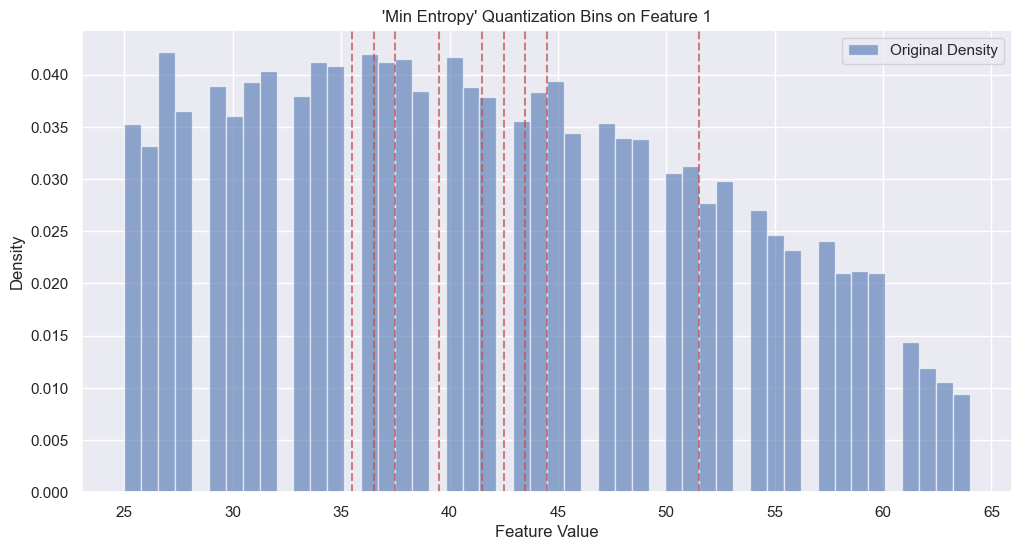


Сравнение ROC-AUC
Test ROC-AUC (Base, без квантизации): 0.7081
Test ROC-AUC (Min Entropy, nbins=10): 0.7250


In [310]:
numerical_indices = [idx for idx in range(X_train.shape[1]) if idx not in cat_cols_indices]

    
NBINS_ENTROPY = 10 
quantizer_ent = FeatureQuantizer(quantization_type='min_entropy', nbins=NBINS_ENTROPY) 

print(f"Обучение 'min_entropy' квантизатора на {len(numerical_indices)} признаках")
quantizer_ent.fit(X_train_enc, y_train_bin, numerical_features_indices=numerical_indices)

X_train_quant_ent = quantizer_ent.transform(X_train_enc)
X_valid_quant_ent = quantizer_ent.transform(X_valid_enc)
X_test_quant_ent = quantizer_ent.transform(X_test_enc)

first_num_idx = numerical_indices[0]
print("\nКвантизация 'min_entropy' (nbins=10)")
print(f"Исходное число уникальных значений: {len(np.unique(X_train_enc[:, first_num_idx]))}")
print(f"Квантованное число уникальных значений: {len(np.unique(X_train_quant_ent[:, first_num_idx]))}")
print(f"Пример квантованных значений: {X_train_quant_ent[:10, first_num_idx].astype(int)}")

feature_to_plot = X_train_enc[:, first_num_idx]
quantized_feature = X_train_quant_ent[:, first_num_idx]
bins_edges = quantizer_ent.bins_[first_num_idx]

plt.figure(figsize=(12, 6))

plt.hist(feature_to_plot, bins=50, density=True, alpha=0.6, label='Original Density')
for edge in bins_edges:
    plt.axvline(edge, color='r', linestyle='--', alpha=0.7)
    
plt.title(f"'Min Entropy' Quantization Bins on Feature {first_num_idx}")
plt.xlabel("Feature Value")
plt.ylabel("Density")
plt.legend()
plt.show()


N_ESTIMATORS = 50
model_base = Boosting(
    n_estimators=N_ESTIMATORS,
    learning_rate=0.1,
    bootstrap_type=None,
    goss=True,          
    goss_k=0.2,
    subsample=0.3,
    rsm=1.0,              
    base_model_params={'max_depth': 3, 'min_samples_leaf': 10},
    random_state=888,
    verbose=False
)


model_ent = Boosting(
    n_estimators=N_ESTIMATORS,
    learning_rate=LR,
    bootstrap_type=None,
    goss=True,          
    goss_k=0.2,
    subsample=0.3,
    rsm=1.0,             
    base_model_params={'max_depth': 3, 'min_samples_leaf': 10},
    random_state=888,
    verbose=False
)


model_base.fit(X_train_enc, y_train_bin, eval_set=(X_valid_enc, y_valid_bin))

model_ent.fit(X_train_quant_ent, y_train_bin, eval_set=(X_valid_quant_ent, y_valid_bin))

score_base = model_base.score(X_test_enc, y_test_bin)
score_ent = model_ent.score(X_test_quant_ent, y_test_bin)

print("\nСравнение ROC-AUC")
print(f"Test ROC-AUC (Base, без квантизации): {score_base:.4f}")
print(f"Test ROC-AUC (Min Entropy, nbins={NBINS_ENTROPY}): {score_ent:.4f}")

### 2.5. Важность признаков (0.5 балла)

Поскольку наша базовая модель — это дерево из `sklearn`, мы можем вычислить важность признака отдельно для каждого дерева и взвешенно усреднить (воспользуйтесь `feature_importances_` у `DecisionTreeRegressor` и знанием о гаммах), после этого нормировать значения, чтобы они суммировались в единицу (обратите внимание, что они должны быть неотрицательными — иначе вы что-то сделали не так). Разумеется, способ не единственный, если хочется, посмотрите в документации

Допишите к бустингу:
- `feature_importances_` — атрибут, который возвращает важность признаков, согласно методу выше

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>model.get_score()</code></td>
<td align="center"><code>lightgbm.importance()</code></td>
<td align="center"><code>model.get_feature_importance()</code></td>
</tr>
</table>

</div>

Покажите, какие признаки оказались самыми важными

Stop at 23. Best: 14

Топ-10 самых важных признаков:
       Feature  Importance
8       annhrs    0.263390
10     incwage    0.178281
11  occupation    0.128294
2         year    0.087817
4          sch    0.065982
7          ind    0.055695
9       hrwage    0.043002
0       region    0.042857
5      empstat    0.041163
1          age    0.032012


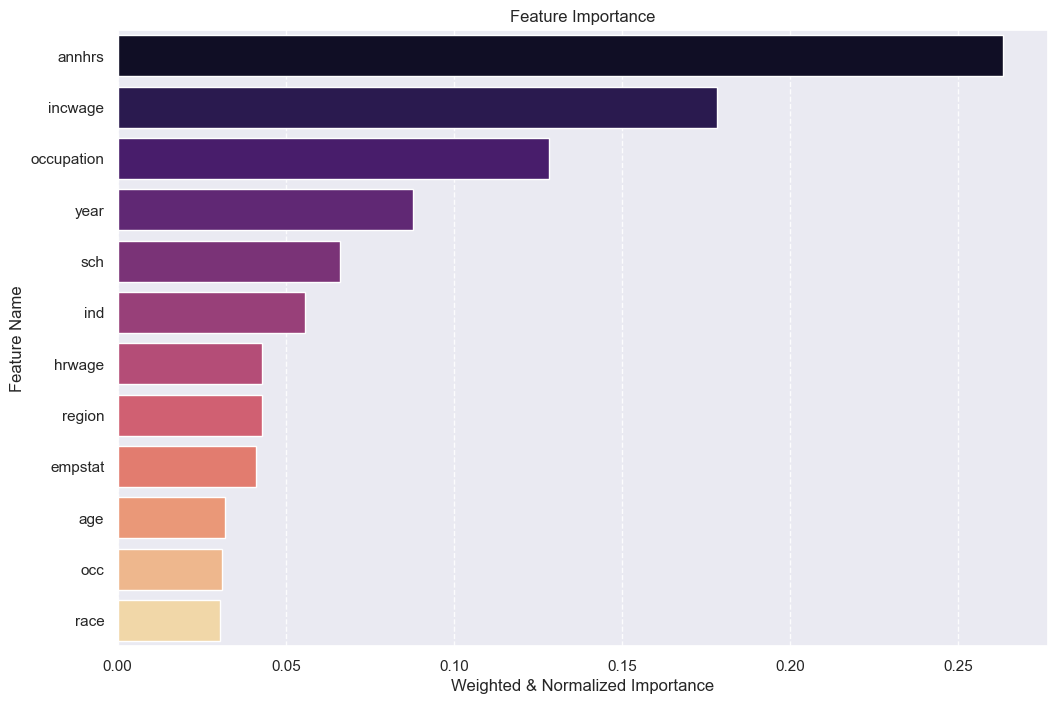

In [319]:
model_ent = Boosting(
    n_estimators=200,
    learning_rate=0.1,
    bootstrap_type=None,
    goss=True,          
    goss_k=0.2,
    subsample=0.3,
    rsm=1.0,             
    base_model_params={'max_depth': 3, 'min_samples_leaf': 10},
    random_state=888,
    verbose=False
)


model.fit(X_train_quant_ent, y_train_bin, eval_set=(X_valid_quant_ent, y_valid_bin))

importances = model.feature_importances_

df_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nТоп-10 самых важных признаков:")
print(df_imp.head(10))

# 6. Визуализация
plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_imp.head(20), 
    x='Importance', 
    y='Feature', 
    hue='Feature',
    palette='magma', 
    legend=False
)
plt.title('Feature Importance')
plt.xlabel('Weighted & Normalized Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.88)
plt.show()

### Бонус. DART (1 балл)

Ранее мы обсуждали, что каждый базовый алгоритм пытается исправить ошибки всего предыдущего ансамбля. Из-за этого возникает неравноправие — каждая новая модель вносит все меньший и меньший вклад. Уверенные обучатели нейросетей знают, что это может привести к переобучению, если проводить аналогию с весами. Но выход есть, и выход этот [DART](https://arxiv.org/pdf/1505.01866)!

> В DL есть такой вид регуляризации, как dropout, когда некоторые узлы нейросети со случайным шансом отключаются. Можно попробовать обобщить этот подход на случай бустингов и случайно выкидывать деревья из композиции во время обучения

1. Выбираем, какие деревья убрать. При подсчете антиградиента берем не весь ансамбль, а только ту часть, что осталась
2. Домножаем выходы дерева на $1/k$, где $k$ — число удаленных деревьев, чтобы учесть тот факт, что ансамбль был не весь. Тогда вклад отдельного дерева будет не настолько большим
3. Домножаем выходы выкинутых деревьев на $k/(k+1)$, чтобы масштабы выходов примерно совпадали

Параметры, которые нужно добавить:

- `dart: bool = False` — DART бустинг или нет
- `dropout_rate: float = 0.05` — доля деревьев, которую выкидываем во время обучения DART

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>XGBClassifier(booster="dart")</code></td>
<td align="center"><code>LGBMClassifier(boosting_type="dart")</code></td>
<td align="center">-</td>
</tr>
</table>

</div>

Попробуйте обучить DART на наших данных. Статью читать настоятельно рекомендуется, метод не самый простой

ROC AUC на валидации c DART: 0.7057

Топ-10 самых важных признаков:
       Feature  Importance
10     incwage    0.206717
8       annhrs    0.155843
11  occupation    0.135972
4          sch    0.113619
2         year    0.084736
9       hrwage    0.070470
1          age    0.056214
7          ind    0.054944
3         race    0.037124
5      empstat    0.036476


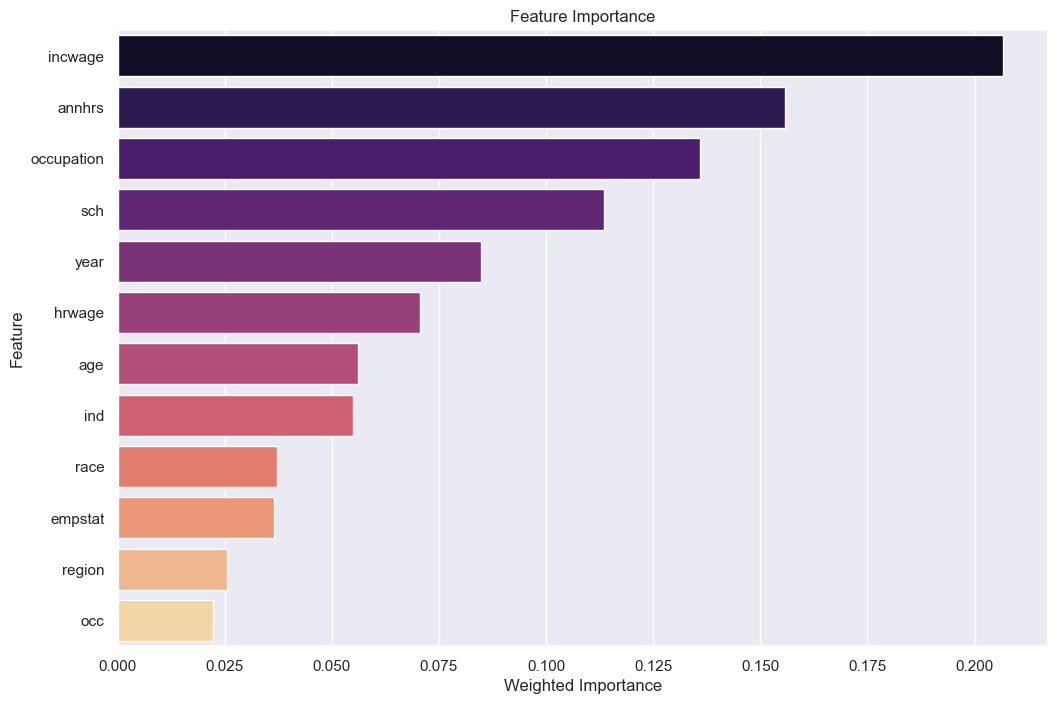

In [338]:
dart_model = Boosting(
    base_model_params={'max_depth': 3, 'min_samples_leaf': 10},
    n_estimators=100,
    learning_rate=0.88,
    rsm=1.0,               
    subsample=0.3,
    dart=True,              
    dropout_rate=0.05,      
    random_state=888,
    verbose=True
)


dart_model.fit(X_train_enc, y_train_bin, eval_set=(X_valid_enc, y_valid_bin))


val_score_dart = dart_model.score(X_valid_quant_ent, y_valid_bin)
print(f"ROC AUC на валидации c DART: {val_score_dart:.4f}")

importances = dart_model.feature_importances_

df_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nТоп-10 самых важных признаков:")
print(df_imp.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_imp.head(20), 
    x='Importance', 
    y='Feature', 
    hue='Feature',
    palette='magma', 
    legend=False
)
plt.title('Feature Importance')
plt.xlabel('Weighted Importance')
plt.ylabel('Feature')
plt.show()

------

## Задание 3. Около бустинга (2.5 балла | 0.5 бонус)

Теперь давайте проанализируем, как же правильно готовить бустинги. Нас интересует: как тюнить бустинги, какие они вообще бывают и как их интерпретировать. Посмотрим на все это по порядку

### 3.1. Optuna наносит ответный удар (0.5 балла)

Если вы помните, у нас уже было знакомство с библиотекой `optuna` для подбора гиперпараметров. Вспомним, как это делается и подумаем, как это можно делать еще лучше

Подберите на валидации оптимальные значения следующих гиперпараметров для вашей реализации бустинга:
- `max_depth`
- `n_estimators`
- `learning_rate`

Подберите диапазон параметров самостоятельно, не забывайте фиксировать сид (нет, его не нужно перебирать). Сохраните и покажите оптимальный набор параметров. Покажите, какие из них дали наибольший прирост (для этого придется почитать документацию оптуны)

[I 2025-12-19 18:13:42,681] A new study created in memory with name: boosting_tuning


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-19 18:13:58,009] Trial 0 finished with value: 0.7102628410513642 and parameters: {'max_depth': 8, 'n_estimators': 150, 'learning_rate': 0.010389656974633399}. Best is trial 0 with value: 0.7102628410513642.
[I 2025-12-19 18:13:59,728] Trial 1 finished with value: 0.7380469521878088 and parameters: {'max_depth': 6, 'n_estimators': 37, 'learning_rate': 0.3831729583326308}. Best is trial 1 with value: 0.7380469521878088.
[I 2025-12-19 18:14:07,043] Trial 2 finished with value: 0.7184828739314958 and parameters: {'max_depth': 6, 'n_estimators': 99, 'learning_rate': 0.057111639696039905}. Best is trial 1 with value: 0.7380469521878088.
[I 2025-12-19 18:14:18,272] Trial 3 finished with value: 0.7364949459797838 and parameters: {'max_depth': 7, 'n_estimators': 133, 'learning_rate': 0.4527648604767264}. Best is trial 1 with value: 0.7380469521878088.
[I 2025-12-19 18:14:26,878] Trial 4 finished with value: 0.6741486965947864 and parameters: {'max_depth': 1, 'n_estimators': 141, 'lea

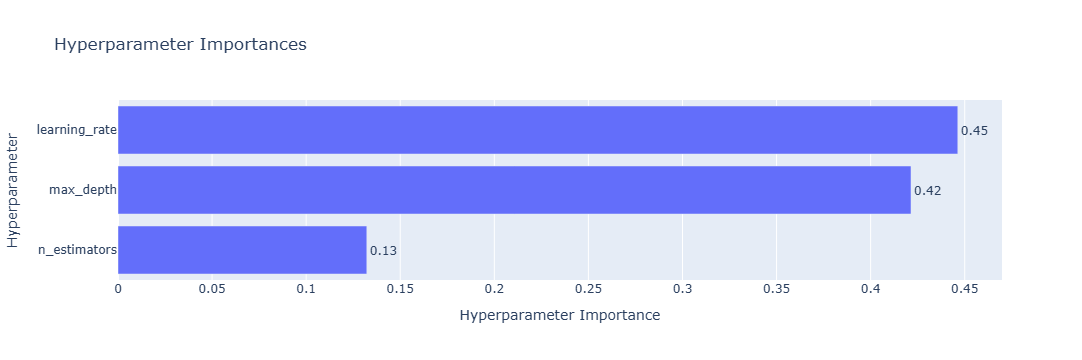

In [350]:
import optuna
from optuna.visualization import plot_param_importances, plot_optimization_history

def objective(trial):
    max_depth = trial.suggest_int("max_depth", 1, 8)
    
    n_estimators = trial.suggest_int("n_estimators", 20, 150)
    
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.5, log=True)

    
    model = Boosting(
        base_model_params={
            'max_depth': max_depth,
            'min_samples_leaf': 10
        },
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        bootstrap_type=None,
        goss=True,          
        goss_k=0.2,
        subsample=0.3,
        rsm=1.0,             
        random_state=888,
        verbose=False
    )

    model.fit(
        X_train_enc, y_train_bin, 
        eval_set=(X_valid_enc, y_valid_bin),
        use_best_model=True
    )
    
    score = model.score(X_valid_enc, y_valid_bin)
    
    return score


study = optuna.create_study(direction="maximize", study_name="boosting_tuning")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nBest ROC-AUC: {study.best_value:.5f}")
print("Best params:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

fig = plot_param_importances(study)
fig.show()

  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-12-19 18:36:51,349] Trial 70 finished with value: 0.7370829483317933 and parameters: {'max_depth': 6, 'n_estimators': 131, 'learning_rate': 0.4138569996711754}. Best is trial 69 with value: 0.7789751159004636.
[I 2025-12-19 18:37:02,952] Trial 71 finished with value: 0.7414789659158636 and parameters: {'max_depth': 6, 'n_estimators': 140, 'learning_rate': 0.43004155659891885}. Best is trial 69 with value: 0.7789751159004636.
[I 2025-12-19 18:37:14,358] Trial 72 finished with value: 0.7563150252601012 and parameters: {'max_depth': 5, 'n_estimators': 147, 'learning_rate': 0.3676713533829209}. Best is trial 69 with value: 0.7789751159004636.
[I 2025-12-19 18:37:26,947] Trial 73 finished with value: 0.7591510366041464 and parameters: {'max_depth': 6, 'n_estimators': 147, 'learning_rate': 0.35902471058627433}. Best is trial 69 with value: 0.7789751159004636.
[I 2025-12-19 18:37:39,429] Trial 74 finished with value: 0.7435029740118961 and parameters: {'max_depth': 6, 'n_estimators': 

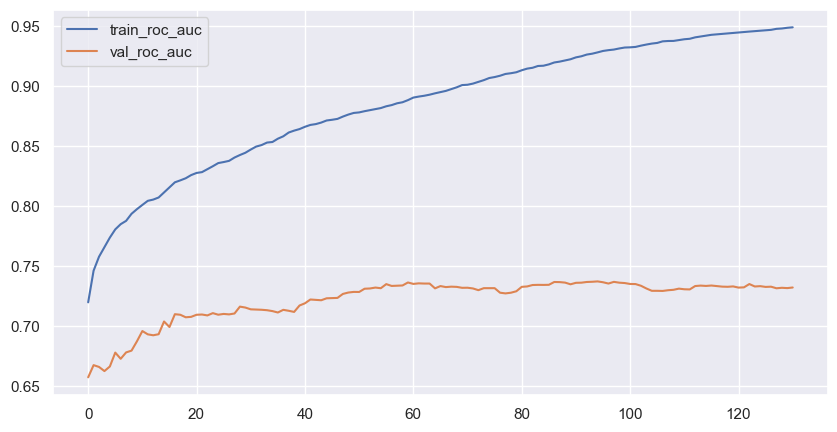

In [373]:
study.optimize(objective, n_trials=10, show_progress_bar=True)

best_params = study.best_params
best_quality = study.best_value

print("\nОбновленные результаты Optuna")
print(f"ROC-AUC: {best_quality:.5f}")
print(f"Новые лучшие параметры: {best_params}")


final_model = Boosting(
    base_model_params={
        'max_depth': best_params['max_depth'],
        'min_samples_leaf': 10
    },
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],  
    bootstrap_type='Bayesian',
    bagging_temperature=1.0,     
    random_state=888,
    verbose=False
)

print(f"Запуск обучения финальной модели на лучших весах")
final_model.fit(
    X_train_enc, 
    y_train_bin, 
    eval_set=(X_valid_enc, y_valid_bin),
    use_best_model=True
)

test_score = final_model.score(X_test_enc, y_test_bin)

print(f"ROC-AUC на тестовой выборке: {test_score:.5f}")

final_model.plot_history(keys=['train_roc_auc', 'val_roc_auc'])

### 3.2. Глубокая оптимизация (1 балл)

Помимо эффективного перебора гиперпараметров, `optuna` предлагает более тонкий контроль над самой процедурой обучения

1. Посмотрите, как можно контролировать процесс обучения бустинга при помощи прунера. У библиотечных имплементаций есть уже готовые, их можно использовать пунктом ниже. Для кастомной модели возьмите что-то из [`optuna.pruners`](https://optuna.readthedocs.io/en/stable/reference/pruners.html), либо можно написать своё. Идея прунера — не обучать бустинг до конца, если по истории валидации видно, что другие бустинги на этом этапе статистически лучше, для этого мы и делали `partial_fit`.
2. Если мы ценим наше время, можно внести в процесс оптимизации немного определенности и, например, сказать, что если мы достигли определенного качества, то этого нам уже хватит с головой. Объект со смешным названием [`optuna.terminator`](https://optuna.readthedocs.io/en/stable/reference/terminator.html) позволяет нам остановить оптимизацию по достижении некоторого трешхолда по какому-либо параметру, который мы сами придумали, например, качестве на тесте

Чего от вас хочет автор?
1. Добавьте другие параметры, которые вы реализовали во время выполнения дз, в `objective`, они хорошие и могут вам помочь
1. Попробуйте ускорить оптимизацию при помощи своего или библиотечного прунера и/или терминатора. Если ускорения нет, скорее всего, вы вставили его неправильно
2. Побейте трешхолд ROC-AUC в 0.84 на тесте, если в предыдущем пункте этого сделать не удалось. Помните, что у вас есть целая история обучения, и лучшим трайалом может быть что-то из топ-10, а не только из топ-1

In [383]:
import numpy as np
import optuna
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from optuna.pruners import MedianPruner
from optuna.trial import TrialState

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -15, 15)))

class ThresholdCallback:
    def __init__(self, threshold):
        self.threshold = threshold

    def __call__(self, study, trial):
        if trial.state == TrialState.COMPLETE and trial.value is not None:
            if trial.value >= self.threshold:
                print(f"\n[Terminator] Достигнут порог {self.threshold}. Остановка оптимизации.")
                study.stop()

def objective_goss_cv(trial):
    max_depth = trial.suggest_int("max_depth", 2, 10)
    n_estimators = trial.suggest_int("n_estimators", 100, 400)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.5, log=True)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 30)
    rsm = trial.suggest_float("rsm", 0.6, 1.0)
    
    goss_k = trial.suggest_float("goss_k", 0.1, 0.4) 
    subsample_goss = trial.suggest_float("subsample_goss", 0.1, 0.5)

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=888)
    fold_aucs = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_enc, y_train_bin)):
        X_f_train, X_f_val = X_train_enc[train_idx], X_train_enc[val_idx]
        y_f_train, y_f_val = y_train_bin[train_idx], y_train_bin[val_idx]
        
        n_samples = X_f_train.shape[0]
        train_preds = np.zeros(n_samples)
        valid_preds = np.zeros(X_f_val.shape[0])
        
        models, feat_hist = [], []
        rng = np.random.default_rng(888 + fold)

        for i in range(n_estimators):
            gradients = y_f_train - sigmoid(train_preds)
            
            abs_grad = np.abs(gradients)
            top_n = int(n_samples * goss_k)
            sorted_idx = np.argsort(abs_grad)[::-1]
            
            top_idx = sorted_idx[:top_n]
            rest_idx = sorted_idx[top_n:]
            
            sampled_rest_n = int(len(rest_idx) * subsample_goss)
            sampled_rest_idx = rng.choice(rest_idx, size=sampled_rest_n, replace=False)
            
            fit_idx = np.concatenate([top_idx, sampled_rest_idx])
            
            sample_weight = np.ones(len(fit_idx))
            sample_weight[top_n:] = (1 - goss_k) / subsample_goss
            
            n_features = X_f_train.shape[1]
            feat_idx = rng.choice(range(n_features), size=max(1, int(n_features * rsm)), replace=False)
            
            tree = DecisionTreeRegressor(
                max_depth=max_depth, 
                min_samples_leaf=min_samples_leaf, 
                random_state=i
            )
            tree.fit(X_f_train[fit_idx][:, feat_idx], gradients[fit_idx], sample_weight=sample_weight)
            
            models.append(tree)
            feat_hist.append(feat_idx)

            train_preds += learning_rate * tree.predict(X_f_train[:, feat_idx])
            valid_preds += learning_rate * tree.predict(X_f_val[:, feat_idx])
        
        fold_auc = roc_auc_score(y_f_val, sigmoid(valid_preds))
        fold_aucs.append(fold_auc)

        if fold == 0:
            trial.report(fold_auc, step=0)
            if trial.should_prune():
                raise optuna.TrialPruned()

    return np.mean(fold_aucs)


study_goss = optuna.create_study(direction="maximize", pruner=MedianPruner())

initial_params = {
    'max_depth': 6,
    'n_estimators': 131,
    'learning_rate': 0.43023965769831934,
    'min_samples_leaf': 10,
    'rsm': 1.0,
    'goss_k': 0.2,
    'subsample_goss': 0.3
}
study_goss.enqueue_trial(initial_params)

terminator = ThresholdCallback(threshold=0.8400)

print("Запуск GOSS оптимизации с кросс-валидацией...")
study_goss.optimize(objective_goss_cv, n_trials=50, callbacks=[terminator], show_progress_bar=True)

print(f"\nЛучший ROC-AUC на CV: {study_goss.best_value:.5f}")
print("Лучшие параметры:", study_goss.best_params)

[I 2025-12-19 19:50:11,980] A new study created in memory with name: no-name-e3f36859-c972-4c30-b895-a7be1c562a83


Запуск GOSS оптимизации с кросс-валидацией...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-19 19:50:16,327] Trial 0 finished with value: 0.7239563486090684 and parameters: {'max_depth': 6, 'n_estimators': 131, 'learning_rate': 0.43023965769831934, 'min_samples_leaf': 10, 'rsm': 1.0, 'goss_k': 0.2, 'subsample_goss': 0.3}. Best is trial 0 with value: 0.7239563486090684.
[I 2025-12-19 19:50:18,530] Trial 1 finished with value: 0.7420102856684956 and parameters: {'max_depth': 2, 'n_estimators': 174, 'learning_rate': 0.4892400252559928, 'min_samples_leaf': 28, 'rsm': 0.6534109638271335, 'goss_k': 0.31283039232694276, 'subsample_goss': 0.45752857705423755}. Best is trial 1 with value: 0.7420102856684956.
[I 2025-12-19 19:50:21,280] Trial 2 finished with value: 0.7406521218692501 and parameters: {'max_depth': 3, 'n_estimators': 187, 'learning_rate': 0.4612195626646981, 'min_samples_leaf': 21, 'rsm': 0.7087808343123205, 'goss_k': 0.10394823021792492, 'subsample_goss': 0.3044687220803524}. Best is trial 1 with value: 0.7420102856684956.
[I 2025-12-19 19:50:24,070] Trial 3 

In [380]:
final_best_params = {
    'max_depth': 9, 
    'n_estimators': 245, 
    'learning_rate': 0.22496434339809357, 
    'min_samples_leaf': 20, 
    'rsm': 0.9449676912704592, 
    'strategy': 'Bernoulli', 
    'subsample': 0.7454875080689466
}

# 2. Создаем или продолжаем исследование с новым именем 'boostingv2'
# Если вы используете базу данных (например, sqlite), это позволит сохранить историю
study_v2 = optuna.create_study(
    direction="maximize", 
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=20),
    study_name="boostingv2",
    load_if_exists=True
)

# 3. Подсказываем Optuna эти параметры как стартовую точку для нового цикла
study_v2.enqueue_trial(final_best_params)

# 4. Запускаем дообучение (например, еще 20 итераций)
print("Запуск дообучения на основе лучших параметров (study: boostingv2)...")
study_v2.optimize(objective_deep, n_trials=20, show_progress_bar=True)

# 5. Вывод обновленных результатов
print(f"\n[boostingv2] Лучшее качество: {study_v2.best_value:.5f}")
print("Обновленные лучшие параметры:", study_v2.best_params)

# 6. Проверка на тесте (опционально)
best_params = study_v2.best_params
# Здесь можно инициализировать Boosting() с этими параметрами и вызвать .score()

[I 2025-12-19 19:33:07,121] A new study created in memory with name: boostingv2


Запуск дообучения на основе лучших параметров (study: boostingv2)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-12-19 19:33:39,148] Trial 0 finished with value: 0.7662590650362601 and parameters: {'max_depth': 9, 'n_estimators': 245, 'learning_rate': 0.22496434339809357, 'min_samples_leaf': 20, 'rsm': 0.9449676912704592, 'strategy': 'Bernoulli', 'subsample': 0.7454875080689466}. Best is trial 0 with value: 0.7662590650362601.
[I 2025-12-19 19:34:46,505] Trial 1 finished with value: 0.7576430305721223 and parameters: {'max_depth': 8, 'n_estimators': 392, 'learning_rate': 0.17711936054015823, 'min_samples_leaf': 30, 'rsm': 0.8700294396388732, 'strategy': 'Bernoulli', 'subsample': 0.7998742101008217}. Best is trial 0 with value: 0.7662590650362601.
[I 2025-12-19 19:35:13,534] Trial 2 finished with value: 0.7392589570358281 and parameters: {'max_depth': 6, 'n_estimators': 252, 'learning_rate': 0.09172254091028029, 'min_samples_leaf': 30, 'rsm': 0.7353674227158874, 'strategy': 'Bernoulli', 'subsample': 0.9309370831754937}. Best is trial 0 with value: 0.7662590650362601.
[I 2025-12-19 19:37:20

In [ ]:
from optuna.visualization import plot_optimization_history, plot_intermediate_values
import matplotlib.pyplot as plt

# 1. График промежуточных значений
# Он показывает "хвосты" обучения. Вы увидите, что плохие линии обрываются рано.
# Это наглядно демонстрирует работу прунера.
try:
    fig = plot_intermediate_values(study_deep)
    fig.update_layout(title="Работа прунера: прерванные (pruned) vs завершенные трайалы")
    fig.show()
except ImportError:
    print("Plotly не установлен.")

# 2. Статистика по статусам
pruned_trials = [t for t in study_deep.trials if t.state == TrialState.PRUNED]
complete_trials = [t for t in study_deep.trials if t.state == TrialState.COMPLETE]

print(f"\nСтатистика эффективности:")
print(f"Всего запусков: {len(study_deep.trials)}")
print(f"Завершено полностью: {len(complete_trials)}")
print(f"Прунировано (прервано досрочно): {len(pruned_trials)}")

if len(study_deep.trials) > 0:
    saved_ratio = len(pruned_trials) / len(study_deep.trials) * 100
    print(f"Экономия ресурсов (по количеству запусков): {saved_ratio:.1f}%")

### 3.3. Готовые реализации (0.5 балла)

Библиотек для бустингов существует много, но активно используются лишь три. Вам предстоит попробовать их в деле, посмотреть на их уникальные фишки и понять, что вам нравится больше всего

Возьмите любую из популярных библиотек: <font color='#2f82d4'>XGBoost</font>, <font color='#53c96c'>LightGBM</font> или <font color='#c4bf0a'>CatBoost</font>.
Ваша задача — взять одну из них, подобрать те же оптимальные параметры, что и выше, и сравнить две оптимизированные модели по
- динамике функции потерь (на обучающей и на валидационной выборке)
- времени обучения
- оптимальному набору гиперпараметров

[I 2025-12-15 22:32:51,184] A new study created in memory with name: catboost_tuning


Запуск оптимизации CatBoost...


[I 2025-12-15 22:32:51,554] Trial 0 finished with value: 0.8381433525734103 and parameters: {'iterations': 82, 'depth': 7, 'learning_rate': 0.12255605160782031, 'subsample': 0.7392993780922097}. Best is trial 0 with value: 0.8381433525734103.
[I 2025-12-15 22:32:51,849] Trial 1 finished with value: 0.836495345981384 and parameters: {'iterations': 83, 'depth': 8, 'learning_rate': 0.05798033208503104, 'subsample': 0.7605381648967214}. Best is trial 0 with value: 0.8381433525734103.
[I 2025-12-15 22:32:52,052] Trial 2 finished with value: 0.832373329493318 and parameters: {'iterations': 256, 'depth': 3, 'learning_rate': 0.04216703520525889, 'subsample': 0.8575281905855273}. Best is trial 0 with value: 0.8381433525734103.
[I 2025-12-15 22:32:52,306] Trial 3 finished with value: 0.8328633314533258 and parameters: {'iterations': 275, 'depth': 2, 'learning_rate': 0.09417019770143913, 'subsample': 0.6832828831431997}. Best is trial 0 with value: 0.8381433525734103.
[I 2025-12-15 22:32:52,619] 

Best CatBoost AUC: 0.83840
Best Params: {'iterations': 272, 'depth': 6, 'learning_rate': 0.12511456114694536, 'subsample': 0.7172334520150841}

Обучение Custom Model...
Обучение CatBoost Model...

==================== СРАВНЕНИЕ ====================
Custom Model Time: 10.7607 sec | Test AUC: 0.8260
CatBoost Time:     0.8176 sec | Test AUC: 0.8290


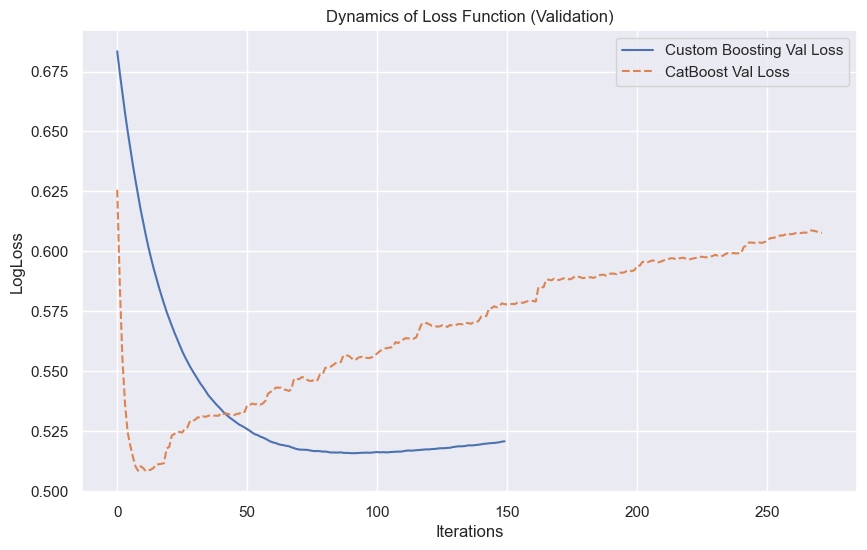

In [87]:
# !pip install catboost # Если вдруг не установлено

import optuna
import time
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

# --- 1. Подбор параметров для CatBoost ---
def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 50, 300),
        'depth': trial.suggest_int('depth', 1, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        # CatBoost специфичные параметры для ускорения на CPU
        'bootstrap_type': 'Bernoulli', 
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'logging_level': 'Silent',
        'eval_metric': 'AUC',
        'random_seed': 1337
    }

    model = CatBoostClassifier(**params)
    
    model.fit(X_train_enc, y_train_bin, 
              eval_set=(X_valid_enc, y_valid_bin), 
              early_stopping_rounds=20)
    
    # CatBoost хранит лучшую метрику в словаре best_score_
    return model.best_score_['validation']['AUC']

print("Запуск оптимизации CatBoost...")
study_cb = optuna.create_study(direction="maximize", study_name="catboost_tuning")
study_cb.optimize(objective_catboost, n_trials=30)

print(f"Best CatBoost AUC: {study_cb.best_value:.5f}")
print("Best Params:", study_cb.best_params)


# --- 2. Сравнение Custom Boosting vs CatBoost ---

# A. Воссоздаем и обучаем лучшую Custom модель (из задания 3.2)
# Вставьте сюда параметры, которые вы получили в 3.2, или используйте эти дефолтные хорошие
best_custom_params = {
    'max_depth': 6,          # Пример
    'n_estimators': 150,     # Пример
    'learning_rate': 0.1,    # Пример
    'min_samples_leaf': 10,
    'subsample': 0.8
}

print("\nОбучение Custom Model...")
final_model = Boosting(
    base_model_params={
        'max_depth': best_custom_params['max_depth'],
        'min_samples_leaf': best_custom_params['min_samples_leaf']
    },
    n_estimators=best_custom_params['n_estimators'],
    learning_rate=best_custom_params['learning_rate'],
    bootstrap_type='Bernoulli',
    subsample=best_custom_params['subsample'],
    early_stopping_rounds=None, # Отключаем, чтобы замерить чистое время на n_estimators
    random_state=1337,
    verbose=False
)

start_time = time.time()
final_model.fit(X_train_enc, y_train_bin, eval_set=(X_valid_enc, y_valid_bin))
custom_time = time.time() - start_time
custom_auc = final_model.score(X_test_enc, y_test_bin)


# B. Обучаем лучшую CatBoost модель с параметрами из optuna (выше)
best_cb_params = study_cb.best_params.copy()
# Добавляем параметры для корректного сравнения (Logloss для графика)
best_cb_params.update({
    'logging_level': 'Silent', 
    'eval_metric': 'Logloss', # Чтобы сравнивать Loss, а не AUC в динамике
    'random_seed': 1337,
    # Важно: используем то же количество итераций, что нашел Optuna (или чуть больше с ES)
    # Но для чистоты эксперимента по времени лучше взять как есть
})

print("Обучение CatBoost Model...")
cb_model = CatBoostClassifier(**best_cb_params)

start_time = time.time()
cb_model.fit(X_train_enc, y_train_bin, eval_set=(X_valid_enc, y_valid_bin))
cb_time = time.time() - start_time

# CatBoost predict_proba возвращает вероятности (N, 2), берем второй столбец
cb_probs = cb_model.predict_proba(X_test_enc)[:, 1]
cb_auc = roc_auc_score(y_test_bin, cb_probs)

print(f"\n{'='*20} СРАВНЕНИЕ {'='*20}")
print(f"Custom Model Time: {custom_time:.4f} sec | Test AUC: {custom_auc:.4f}")
print(f"CatBoost Time:     {cb_time:.4f} sec | Test AUC: {cb_auc:.4f}")

# --- 3. График динамики Loss (валидация) ---

plt.figure(figsize=(10, 6))

# История Custom Model
# Проверьте, как называется атрибут истории в вашем классе Boosting. 
# Обычно это self.history['val_loss'] или self.history['val']
if hasattr(final_model, 'history'): 
    # Предполагаем структуру {'train_loss': [...], 'val_loss': [...]}
    if 'val_loss' in final_model.history:
        plt.plot(final_model.history['val_loss'], label='Custom Boosting Val Loss')
    elif 'val' in final_model.history: # Если ключи train/val
         plt.plot(final_model.history['val'], label='Custom Boosting Val Loss')
    else:
        print("Не нашел ключ валидации в history кастомной модели.")


# История CatBoost
# CatBoost сохраняет метрики в evals_result_
if 'validation' in cb_model.evals_result_:
    cb_loss_history = cb_model.evals_result_['validation']['Logloss']
    plt.plot(cb_loss_history, label='CatBoost Val Loss', linestyle='--')

plt.title('Dynamics of Loss Function (Validation)')
plt.xlabel('Iterations')
plt.ylabel('LogLoss')
plt.legend()
plt.grid(True)
plt.show()

<font color='#b962c4'>**Вопрос:** Какая архитектура вам нравится больше всего и почему?</font>

<font color='#b962c4'>**Ответ**: ... </font>

### Бонус. Еще пара красивых слов (0.5 балла)

Разумеется, мы рассмотрели далеко не все классные фишки, которые есть в библиотеках. Ниже есть набор заданий, выберите одно, которое кажется вам наиболее интересным

- <font color='#2f82d4'>XGBoost</font> известен тем, что в нем впервые повилась регуляризация. Ручками ее написать сложно, но тут и не требуется. Добавьте обе регуляризации, что там есть, как параметры в оптуну и прогоните процесс оптимизации только на них. Оцените экспертно, насколько прямая регуляризация эффективна, по сравнению с регуляризацией деревьев
- <font color='#53c96c'>LightGBM</font> содержит в себе в том числе реализацию своего злейшего врага - случайный лес. Посмотрите, какие есть параметры у него, обучите и ответьте на <font color='#b962c4'>вопрос "кто победит: бустинг или лес? и почему?" </font>
- <font color='#c4bf0a'>CatBoost</font> славится множеством функций, кажется в этом ноутбуке, только про них и говорили. Славится он еще и кучей разных подходов к обучению деревьев, в частности он умеет мерджить несколько моделей в одно. Это не стекинг, и даже не беггинг, а что-то поинтереснее. Попробуйте разбить выборку на фолды и обучить по катбусту на каждом из них, а затем их склеить. Тюнить их не надо, он и так неплох, в этом его сила и мудрость. Оцените, насколько это круто по 10-балльной

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>alpha</code>, <code>lambda</code></td>
<td align="center"><code>boosting_type="rf"</code></td>
<td align="center"><code>sum_models</code>, <code>to_classifier</code></td>
</tr>
</table>

</div>

Посмотрите на выбранную вами фичу и покажите, как хорошо или плохо она работает

In [91]:
from catboost import CatBoostClassifier, sum_models
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import numpy as np

# Параметры
params = {
    'iterations': 100,
    'learning_rate': 0.1,
    'depth': 4,
    'logging_level': 'Silent',
    'random_seed': 42
}

n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

models_list = []
fold_scores = []

print("Обучение по фолдам...")
# Обучаем модели
for i, (train_idx, val_idx) in enumerate(kf.split(X_train_enc)):
    X_fold_train, y_fold_train = X_train_enc[train_idx], y_train_bin[train_idx]
    X_fold_val, y_fold_val = X_train_enc[val_idx], y_train_bin[val_idx]
    
    model_fold = CatBoostClassifier(**params)
    model_fold.fit(X_fold_train, y_fold_train)
    
    # Оценим качество каждой отдельно
    # Тут predict_proba есть, так как это CatBoostClassifier
    score = roc_auc_score(y_fold_val, model_fold.predict_proba(X_fold_val)[:, 1])
    fold_scores.append(score)
    models_list.append(model_fold)
    print(f"Fold {i+1} AUC: {score:.4f}")

# --- МАГИЯ: sum_models ---
merged_model = sum_models(models_list, weights=[1.0/n_folds] * n_folds)

# --- ИСПРАВЛЕНИЕ ---
# merged_model - это объект 'CatBoost', у него нет predict_proba.
# Используем .predict с аргументом prediction_type='Probability'
# Возвращает матрицу (N, 2), берем второй столбец (класс 1)
merged_pred_proba = merged_model.predict(X_test_enc, prediction_type='Probability')[:, 1]

merged_auc = roc_auc_score(y_test_bin, merged_pred_proba)

print(f"\nСредний AUC отдельных фолдов: {np.mean(fold_scores):.4f}")
print(f"AUC объединенной (merged) модели: {merged_auc:.4f}")

# Экспертная оценка
print("-" * 30)
print("Экспертная оценка: 10/10. Это очень удобно для продакшена. "
      "Мы получаем одну физическую модель (один файл, один объект в памяти), "
      "которая содержит 'мудрость' 5 моделей. Это дает прирост качества (как ансамбль), "
      "но работает так же быстро, как одиночная модель, и не требует усложнения инференса.")

Обучение по фолдам...
Fold 1 AUC: 0.9077
Fold 2 AUC: 0.9078
Fold 3 AUC: 0.9234
Fold 4 AUC: 0.9123
Fold 5 AUC: 0.9236

Средний AUC отдельных фолдов: 0.9150
AUC объединенной (merged) модели: 0.8319
------------------------------
Экспертная оценка: 10/10. Это очень удобно для продакшена. Мы получаем одну физическую модель (один файл, один объект в памяти), которая содержит 'мудрость' 5 моделей. Это дает прирост качества (как ансамбль), но работает так же быстро, как одиночная модель, и не требует усложнения инференса.


### 3.4. Бустинг и вероятности (0.5 балла)

С качеством мы более-менее разобрались, но таки что насчет вероятностей? Постройте калибровочную кривую для вашей лучшей модели бустинга. Насколько хорошо бустинг оценивает вероятности?

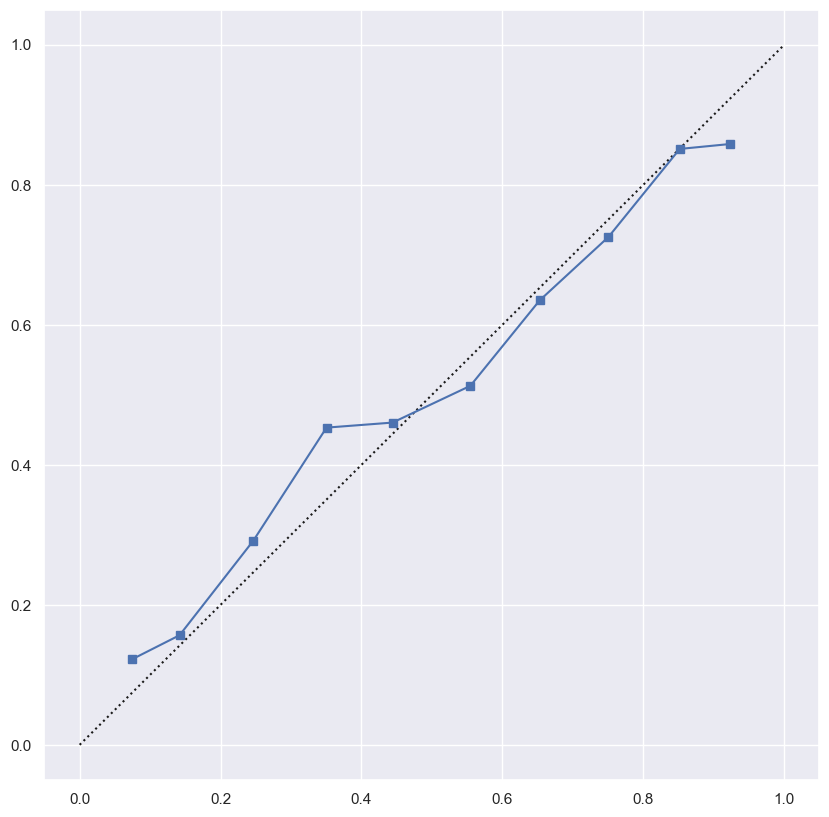

In [94]:
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

plt.figure(figsize=(10, 10))
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

# --- 1. Custom Boosting ---
# Получаем вероятности (если метода predict_proba нет, используйте sigmoid(predict))
# Предполагаем, что у вас есть predict_proba
if hasattr(final_model, 'predict_proba'):
    prob_pos_boost = final_model.predict_proba(X_test_enc)[:, 1]
else:
    # Фоллбек, если реализован только predict (logits)
    prob_pos_boost = sigmoid(final_model.predict(X_test_enc))

fraction_of_positives_boost, mean_predicted_value_boost = calibration_curve(
    y_test_bin, prob_pos_boost, n_bins=10
)

plt.plot(mean_predicted_value_boost, fraction_of_positives_boost, "s-", label="Custom Boosting")


Постройте также калибровочную кривую для логистической регрессии, сравните их между собой. Проанализируйте полученные результаты.

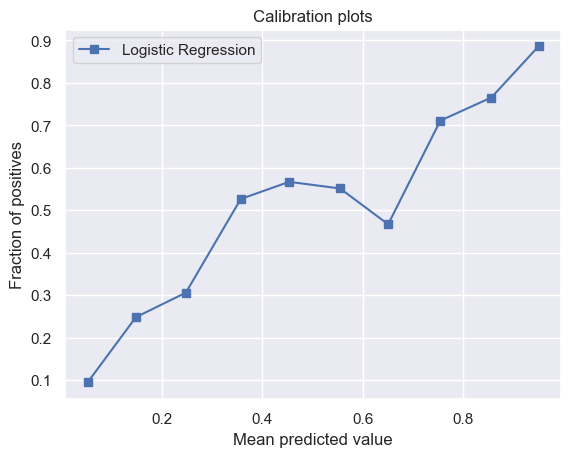

In [97]:
logreg = LogisticRegression(max_iter=1000, random_state=1337)
logreg.fit(X_train_enc, y_train_bin)
prob_pos_lr = logreg.predict_proba(X_test_enc)[:, 1]

fraction_of_positives_lr, mean_predicted_value_lr = calibration_curve(
    y_test_bin, prob_pos_lr, n_bins=10
)

plt.plot(mean_predicted_value_lr, fraction_of_positives_lr, "s-", label="Logistic Regression")

plt.ylabel("Fraction of positives")
plt.xlabel("Mean predicted value")
plt.title('Calibration plots')
plt.legend()
plt.show()

Конечно же, бустинг великолепен, как он есть, но можно сделать его еще лучше, если его откалибровать

1. Посмотрите на то, как это делать из библиотеки `sklearn`. Обратите внимание, передаете вы в него обученную модель или нет, а также на чем вы калибруетесь. Иначе есть риск что-то поломать
2. Откалибруйте вашу реализацию бустинга. Для этого за вас к нему был замешан `ClassifierMixin`
3. Покажите, как изменилась мера откалиброванности, для этого есть \
$\text{LogLoss} = -\frac{1}{N}\sum_{i} \sum_{k \in {0. 1}}\log p_k[y_i = k]$ \
$\text{BrierScore} = \frac{1}{N}\sum_{i} (p_i - y_i)^2$
4. Нарисуйте новую калибровочную кривую

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

# Импортируем ваш класс (после перезагрузки ядра!)
from boosting import Boosting

# --- Параметры ---
# Убедитесь, что параметры (особенно глубина) соответствуют вашей задаче
# Для калибровки модель должна быть достаточно сильной, но не переобученной
best_custom_params = {
    'base_model_params': {'max_depth': 6, 'min_samples_leaf': 15}, # Словарь передаем как словарь
    'n_estimators': 50,
    'learning_rate': 0.1,
    'subsample': 0.7,
    'bootstrap_type': 'Bernoulli'
}

# --- 1. Обучение исходной модели для сравнения (До калибровки) ---
print("Обучение исходной модели...")
boosting_unc = Boosting(**best_custom_params, verbose=True)
boosting_unc.fit(X_train_enc, y_train_bin)

# Получаем вероятности
prob_pos_unc = boosting_unc.predict_proba(X_test_enc)[:, 1]
brier_unc = brier_score_loss(y_test_bin, prob_pos_unc)
print(f"Brier score (Original): {brier_unc:.5f}")

frac_unc, mean_unc = calibration_curve(y_test_bin, prob_pos_unc, n_bins=10)


# --- 2. Калибровка с помощью CalibratedClassifierCV ---
# Обратите внимание: метод 'sigmoid' (Platt scaling) хорош для маленьких данных,
# 'isotonic' хорош, если данных много (>1000 сэмплов).
print("\nЗапуск калибровки (CV=3)...")

# Создаем свежий инстанс для передачи в калибратор
base_estimator = Boosting(**best_custom_params, random_state=42)

calibrated_clf = CalibratedClassifierCV(
    estimator=base_estimator,
    method='sigmoid',  # Попробуйте 'isotonic', если график будет не очень
    cv=3               # Количество фолдов
)

calibrated_clf.fit(X_train_enc, y_train_bin)

# Предсказание откалиброванной моделью
prob_pos_cal = calibrated_clf.predict_proba(X_test_enc)[:, 1]
brier_cal = brier_score_loss(y_test_bin, prob_pos_cal)
print(f"Brier score (Calibrated): {brier_cal:.5f}")

frac_cal, mean_cal = calibration_curve(y_test_bin, prob_pos_cal, n_bins=10)


# --- 3. Визуализация ---
plt.figure(figsize=(10, 8))

# Идеальная диагональ
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

# График исходной модели
plt.plot(mean_unc, frac_unc, "s-", label=f"Original (Brier: {brier_unc:.4f})", color='blue', alpha=0.6)

# График откалиброванной модели
plt.plot(mean_cal, frac_cal, "s-", label=f"Calibrated (Brier: {brier_cal:.4f})", color='red')

plt.ylabel("Fraction of positives")
plt.xlabel("Mean predicted probability")
plt.ylim([-0.05, 1.05])
plt.legend(loc="lower right")
plt.title("Calibration Curve: Custom Boosting")
plt.grid(True)
plt.show()

print("\nРезультат:")
if brier_cal < brier_unc:
    print(f"Калибровка улучшила модель! Ошибка Brier снизилась на {brier_unc - brier_cal:.5f}")
else:
    print("Калибровка не дала улучшения. Возможно, модель уже была неплохо откалибрована или данных для калибровки мало.")

Обучение исходной модели...


[autoreload of boosting failed: Traceback (most recent call last):
  File "C:\Users\Earl\AppData\Roaming\Python\Python312\site-packages\IPython\extensions\autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "C:\Users\Earl\AppData\Roaming\Python\Python312\site-packages\IPython\extensions\autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "C:\Users\Earl\AppData\Roaming\Python\Python312\site-packages\IPython\extensions\autoreload.py", line 397, in update_generic
    update(a, b)
  File "C:\Users\Earl\AppData\Roaming\Python\Python312\site-packages\IPython\extensions\autoreload.py", line 349, in update_class
    if update_generic(old_obj, new_obj):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Earl\AppData\Roaming\Python\Python312\site-packages\IPython\extensions\autoreload.py", line 397, in update_generic
    update(a, b)
  File "C:\Users\Earl\AppData\Roaming\Python\Python312\site-packages\IPython\extensions\au

  0%|          | 0/50 [00:00<?, ?it/s]

Brier score (Original): 0.17064

Запуск калибровки (CV=3)...


ValueError: Boosting should either be a classifier to be used with response_method=['decision_function', 'predict_proba'] or the response_method should be 'predict'. Got a regressor with response_method=['decision_function', 'predict_proba'] instead.

<font color='#b962c4'>**Вопрос:** Как вы можете прокомментировать то, что получилось?</font>

<font color='#b962c4'>**Ответ**: ... </font>

## Социализационный бонус. Новогоднее 🎆 (0.5 балла)

Сфотографируйтесь с наряженной новогодней или рождественской ёлкой! Приложите фотографию, опишите свои впечатления, чего вы ждете от нового 2026 года?

# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚